# [LABORATORY 1] Time Series Fundamentals & Classical Tools

**Table of Contents**
- [Linear Processes](#s1)
  - [AR, MA and ARMA](#s1_1)
  - [ACF and PACF](#s1_2)
  - [Visual Tools](#s1_3)
  - [Statistical Tests](#s1_4)
  - [From ARMA to SARIMAX](#s1_5)
- [Estimation and forecasting with SARIMAX](#s2)
  - [Maximum Likelihood Estimation](#s2_1)
  - [AutoArima](#s2_2)
  - [Mean Prediction](#s2_3)


---

**Exercises**

- [1.1.1](#e1_1_1)
- [1.1.2](#e1_1_2)
- [1.2.1](#e1_2_1)
- [1.2.2](#e1_2_2)
- [1.5.1](#e1_5_1)
- [2.2.1](#e2_2_1)
- [2.3.1](#e2_3_1)
- [2.3.2](#e2_3_2)



In [ ]:
import os
import sys
import warnings
import timeit



import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

import statsmodels.api as sm

if 'google.colab' in sys.modules:
    !pip install -U -qq tsa-course pmdarima numpy==1.26

import pmdarima as pm



import matplotlib.dates as mdates
from scipy import stats

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from scipy.signal import periodogram

from scipy.stats import boxcox
from scipy.special import inv_boxcox

from sklearn.base import BaseEstimator, TransformerMixin


# Config

DATA_FOLDER = ""

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 581.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 22.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
music21 9.9.1 requires numpy>=1.26.4, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 require

<a name="s1"></a>

# Linear Processes


Classical time series modeling techniques are based on **linear processes**, where the dependence on past values, random innovations, and model parameters is linear.

<a name="s1_1"></a>

## AR, MA and ARMA

Denote by $W_t$ a white noise process and let $L$ be the lag operator, defined by
$$
L X_t = X_{t-1}.
$$

An **autoregressive process of order $p$ (AR($p$))** is defined by
$$
X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + W_t.
$$

Using the lag operator, this can be written as
$$
(1 - \phi_1 L - \dots - \phi_p L^p) X_t = W_t.
$$

A **moving average process of order $q$ (MA($q$))** is defined by
$$
X_t = W_t + \theta_1 W_{t-1} + \theta_2 W_{t-2} + \dots + \theta_q W_{t-q}.
$$

Using the lag operator, this becomes
$$
X_t = (1 + \theta_1 L + \dots + \theta_q L^q) W_t.
$$

A general **ARMA($p,q$)** process combines both mechanisms:
$$
X_t = \phi_1 X_{t-1} + \dots + \phi_p X_{t-p}
      + W_t + \theta_1 W_{t-1} + \dots + \theta_q W_{t-q}.
$$

Equivalently, in lag-operator form,
$$
(1 - \phi_1 L - \dots - \phi_p L^p) X_t
=
(1 + \theta_1 L + \dots + \theta_q L^q) W_t.
$$

---

### Stationarity (AR part)

The AR part is **stationary** if all the roots of the polynomial
$$
\phi(z) = 1 - \phi_1 z - \dots - \phi_p z^p
$$
lie **outside the unit circle**.

This guarantees that:

- the process has constant mean and variance,
- the effect of random innovations dies out over time,
- the process admits a $MA(\infty)$ representation.

---

### Invertibility (MA part)

The MA part is **invertible** if all the roots of
$$
\theta(z) = 1 + \theta_1 z + \dots + \theta_q z^q
$$
lie **outside the unit circle**.

Invertibility ensures that:

- the innovations $W_t$ can be uniquely recovered from the observations,
- the model parameters are uniquely identifiable,
- estimation and forecasting are stable.

---

### Hints and interpretation

- **ARMA models are appropriate for modeling stationary processes.**  
  ARMA models provide a **finite-parameter approximation** of the representation raising from the **Wold decomposition**.

- **AR terms model the persistence of the process itself.**  
  An AR component reflects the fact that **past values of the series directly influence future values**.

- **MA terms model the persistence of innovations.**  
  An MA component reflects the fact that **recent innovations continue to affect the process for a few time steps** before dying out.

In other words:
- AR captures how the system propagates its own past.
- MA captures how the system absorbs random disturbances.




---

### Examples

We generate synthetic AR, MA and ARMA time series using the function

```python
gen_arma_sample(phi, theta, ...)
```

This function simulates a realization of an **ARMA(p, q)** process of the form

$$
X_t = \sum_{i=1}^p \phi_i X_{t-i} + W_t + \sum_{j=1}^q \theta_j W_{t-j},
\qquad W_t \sim N(0, \sigma^2).
$$

The main arguments are:
- `phi`: array of AR coefficients $(\phi_1, \dots, \phi_p)$,
- `theta`: array of MA coefficients $(\theta_1, \dots, \theta_q)$,
- `n`: length of the generated sample,
- `sigma`: standard deviation of the innovations.

The function can optionally check **stationarity** (AR part) and **invertibility** (MA part) by verifying that the roots of the characteristic polynomials lie outside the unit circle.

The output is a NumPy array containing a synthetic realization of the specified AR, MA, or ARMA model.


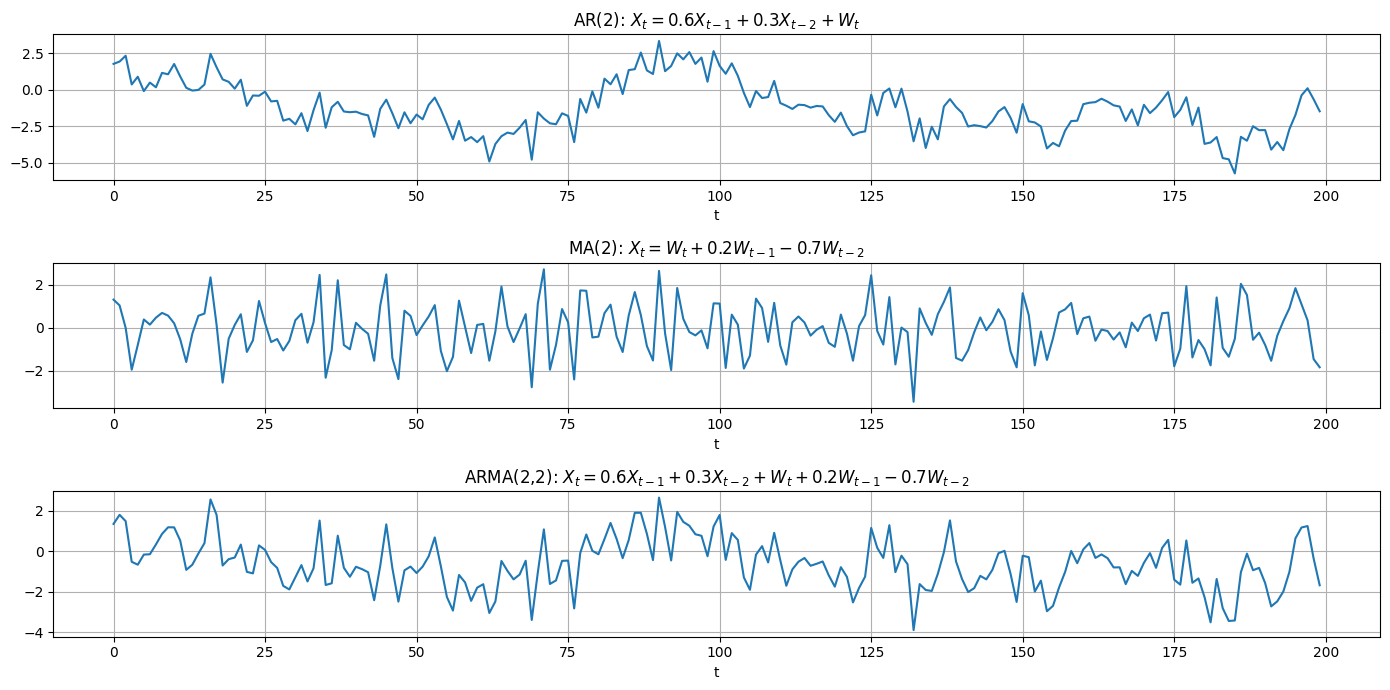

In [ ]:
def gen_arma_sample(phi=None, theta=None, n=200, sigma=1.0, burn_in=200, seed=None,
                    check_stationarity=True, check_invertibility=True):
    """
    Generate a sample from an ARMA(p,q) process:
        X_t = phi_1 X_{t-1} + ... + phi_p X_{t-p} + W_t
              + theta_1 W_{t-1} + ... + theta_q W_{t-q}

    Stationarity (AR part):
      φ(z) = 1 - φ1 z - ... - φp z^p  must have all roots outside |z|=1.

    Invertibility (MA part):
      θ(z) = 1 + θ1 z + ... + θq z^q  must have all roots outside |z|=1.
    """

    if seed is not None:
        np.random.seed(seed)

    phi = np.array(phi, dtype=float) if phi is not None else np.array([], dtype=float)
    theta = np.array(theta, dtype=float) if theta is not None else np.array([], dtype=float)

    p = len(phi)
    q = len(theta)
    m = max(p, q)

    # --- Stationarity check for AR(p) ---
    if check_stationarity and p > 0:
        coeffs_ar = np.r_[-phi[::-1], 1.0]
        roots_ar = np.roots(coeffs_ar)
        if np.any(np.abs(roots_ar) <= 1.0):
            warnings.warn(
                "WARNING: non-stationary AR part detected.\n"
                "Roots of φ(z)=1−φ1 z−...−φp z^p are not all outside the unit circle.\n"
                f"Roots: {roots_ar}",
                RuntimeWarning
            )

    # --- Invertibility check for MA(q) ---
    if check_invertibility and q > 0:
        coeffs_ma = np.r_[theta[::-1], 1.0]
        roots_ma = np.roots(coeffs_ma)
        if np.any(np.abs(roots_ma) <= 1.0):
            warnings.warn(
                "WARNING: non-invertible MA part detected.\n"
                "Roots of θ(z)=1+θ1 z+...+θq z^q are not all outside the unit circle.\n"
                f"Roots: {roots_ma}",
                RuntimeWarning
            )

    N = n + burn_in
    W = np.random.normal(0, sigma, size=N + m)
    X = np.zeros(N + m)

    for t in range(m, N + m):
        if p > 0:
            x_lags = X[t-p:t][::-1]
            ar_part = np.dot(phi, x_lags)
        else:
            ar_part = 0.0

        if q > 0:
            w_lags = W[t-q:t][::-1]
            ma_part = np.dot(theta, w_lags)
        else:
            ma_part = 0.0

        X[t] = ar_part + W[t] + ma_part

    return X[m + burn_in : m + burn_in + n]




# ------------------------------------------------------------
# Generate AR(2), MA(2), ARMA(2,2) using our generator
# ------------------------------------------------------------
n = 200

phi = [0.6, 0.3]
theta = [0.2, -0.7]

X_ar   = gen_arma_sample(phi=phi,   theta=None,  n=n, seed=0)
X_ma   = gen_arma_sample(phi=None,  theta=theta, n=n, seed=0)
X_arma = gen_arma_sample(phi=phi,   theta=theta, n=n, seed=0)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
def arma_title(phi=None, theta=None):
    """
    Build a LaTeX title for AR(p), MA(q), or ARMA(p,q) with arbitrary p,q.
    Convention:
      ARMA(p,q): X_t = sum_{i=1}^p phi_i X_{t-i} + W_t + sum_{j=1}^q theta_j W_{t-j}
    """
    phi = [] if phi is None else list(phi)
    theta = [] if theta is None else list(theta)

    p, q = len(phi), len(theta)

    if p == 0 and q == 0:
        return r"White noise: $X_t = W_t$"

    parts = []

    # AR part
    if p > 0:
        ar_terms = []
        for i, a in enumerate(phi, start=1):
            if i == 1:
                ar_terms.append(rf"{a}X_{{t-1}}")
            else:
                ar_terms.append(rf"{a:+}X_{{t-{i}}}")
        parts.append(" ".join(ar_terms))

        # Innovation term
        parts.append(r"+ W_t")
    else:
        parts.append(r" W_t")


    # MA part
    if q > 0:
        ma_terms = []
        for j, b in enumerate(theta, start=1):
            ma_terms.append(rf"{b:+}W_{{t-{j}}}")

        parts.append(" ".join(ma_terms))

    # Model name
    if p > 0 and q > 0:
        name = rf"ARMA({p},{q})"
    elif p > 0:
        name = rf"AR({p})"
    else:
        name = rf"MA({q})"

    eq = " ".join(parts)
    return rf"{name}: $X_t = {eq}$"


# ------------------------------------------------------------
# Example usage with your generated series (works for any p,q)
# ------------------------------------------------------------
plt.figure(figsize=(14, 7))

plt.subplot(3, 1, 1)
plt.plot(X_ar)
plt.title(arma_title(phi=phi, theta=None))
plt.xlabel("t")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(X_ma)
plt.title(arma_title(phi=None, theta=theta))
plt.xlabel("t")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(X_arma)
plt.title(arma_title(phi=phi, theta=theta))
plt.xlabel("t")
plt.grid(True)

plt.tight_layout()
plt.show()


<a name="e1_1_1"></a>

### Exercise 1.1.1

For each of the following AR processes $X^{(1)}, X^{(2)}, X^{(3)}$, determine whether the process is **stationary**.  
Justify your answer by analyzing the roots of the characteristic polynomial.

1. $X_t = -1.4\,X_{t-2} + W_t$

2. $X_t = 1.6\,X_{t-1} + W_t$

3. $X_t = -0.1\,X_{t-1} + 0.8\,X_{t-2} + W_t$

In [ ]:
# Your solution here

<a name="e1_1_2"></a>

### Exercise 1.1.2

For each AR process $X^{(1)}, X^{(2)}, X^{(3)}$ from Exercise 1.1, generate a sample of length $n=200$ using `gen_arma_sample` and plot the resulting time series.

Pay attention to any warning messages printed by the function (e.g., non-stationarity).


**Solution 1.2**

In [ ]:
# Your solution here

<a name="s1_2"></a>

## ACF and PACF

Let $\{X_t\}$ be a **weakly stationary process**. The **autocovariance function** is defined as
$$
\gamma(h) = \mathrm{Cov}(X_t, X_{t+h}), \quad h \in \mathbb{Z}.
$$

The **autocorrelation function (ACF)** is
$$
\rho(h) = \frac{\gamma(h)}{\gamma(0)} = \mathrm{Corr}(X_t, X_{t+h}).
$$

The ACF measures the linear dependence between observations separated by $h$ time steps.


The **partial autocorrelation function (PACF)** at lag $h$ is defined as
$$
\alpha(h) = \mathrm{Corr}\!\big(X_t, X_{t+h} \,\big|\, X_{t+1}, \dots, X_{t+h-1}\big),
$$
that is, the correlation between $X_t$ and $X_{t+h}$ **after removing the linear effect of the intermediate lags**.

Equivalently, $\alpha(h)$ is the coefficient of $X_{t+h}$ in the linear regression
$$
X_{t+h} = \phi_{h,1} X_{t+h-1} + \dots + \phi_{h,h} X_t + \varepsilon_{t+h},
$$
i.e. $\alpha(h) = \phi_{h,h}$.

---

### Interpretation and identification rules

The empirical ACF and PACF are fundamental exploratory tools used to **guess plausible orders $(p,q)$** for an ARMA model before formal estimation.  
They provide guidance, not exact answers, and must always be complemented by estimation and diagnostic checking.


- **ACF and PACF are theoretically meaningful only for (weakly) stationary processes.**  
  In practice, a non-stationary series often exhibits a **very slowly decaying ACF**, reflecting long-range dependence induced by trends or unit roots.

- An **AR($p$)** process has a theoretical **PACF that cuts off after lag $p$**:
  $$
  \alpha(h) = 0 \quad \text{for all } h > p.
  $$

- An **MA($q$)** process has a theoretical **ACF that cuts off after lag $q$**:
  $$
  \rho(h) = 0 \quad \text{for all } h > q.
  $$

- An **ARMA($p,q$)** process has **neither a finite ACF cutoff nor a finite PACF cutoff**; both functions typically exhibit a fast (often exponential or damped oscillatory) decay.





---

### In practice

We will compute the ACF and PACF using `acf` and `pacf` from  
`statsmodels.tsa.stattools`, and use `plot_acf` and `plot_pacf` from  
`statsmodels.graphics.tsaplots` for visualization.

These functions compute empirical estimates of the ACF and PACF and display them together with confidence intervals at level $\alpha$, centered at zero, to help identify which autocorrelations are significantly different from zero.

⚠️ The confidence intervals are computed **individually for each lag**, not jointly over all lags.  
They should therefore be interpreted as **indicative rather than definitive**: even for a pure white noise process, some sample autocorrelations is expected to fall outside the bands purely by chance.

In [ ]:
from statsmodels.tsa.stattools import acf, pacf

print("X_ar acf: ", acf(X_ar, nlags=5))
print("X_ar pacf: ",pacf(X_ar, nlags=5))

X_ar acf:  [1.         0.80349532 0.77307972 0.68596096 0.62584005 0.56835095]
X_ar pacf:  [ 1.          0.80753298  0.37017134  0.00105175 -0.01601678  0.0085789 ]


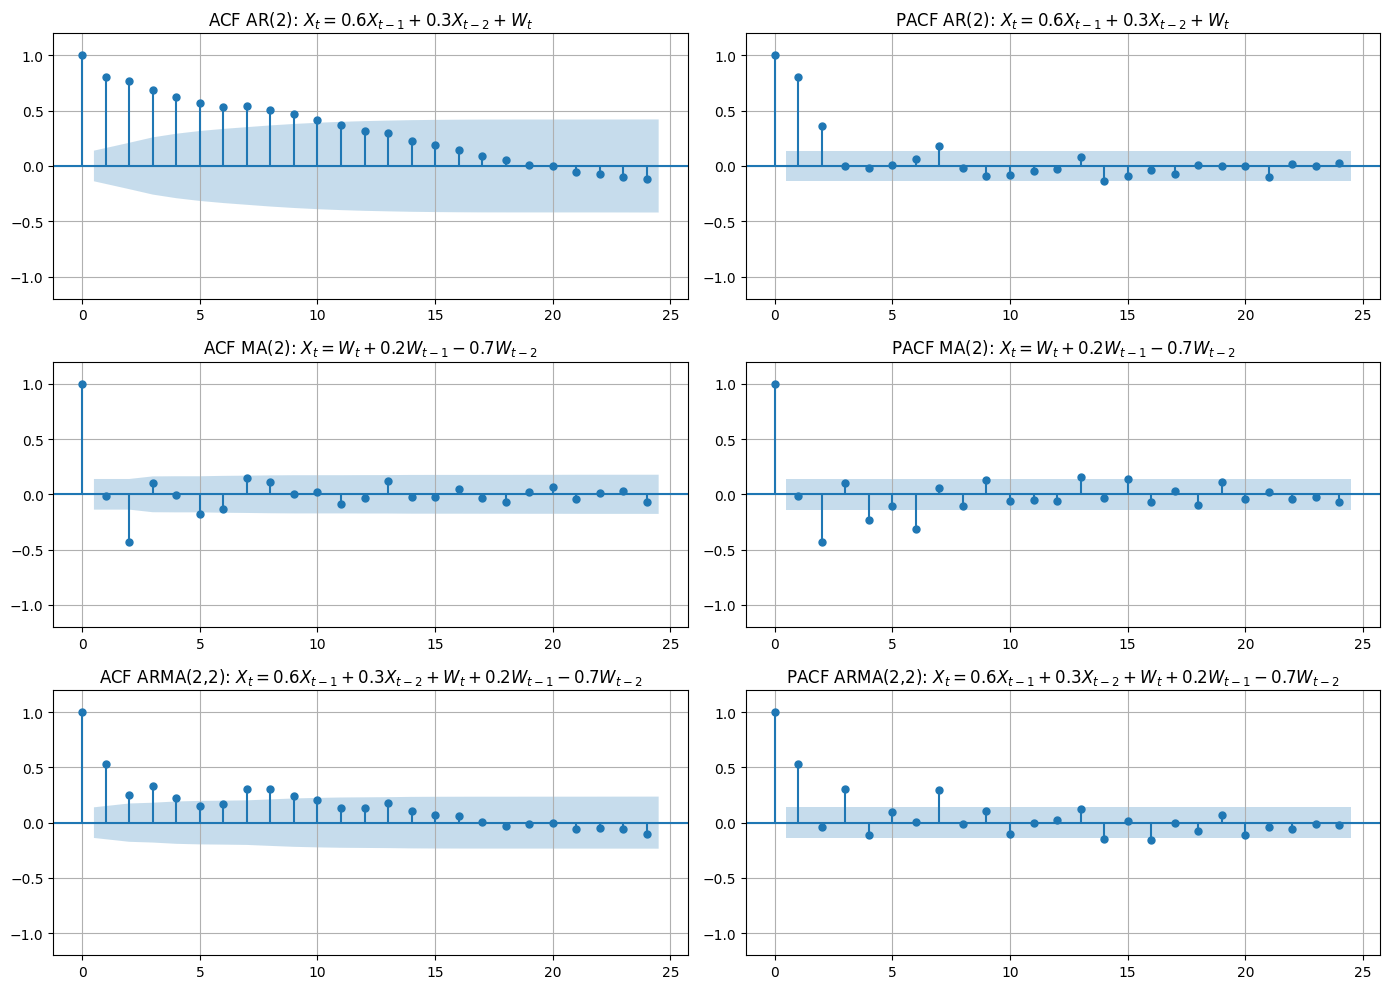

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

lags = 25

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

alpha = 0.05

# --- AR ---

plot_acf(X_ar, ax=axes[0, 0], alpha=alpha)
axes[0, 0].set_title("ACF " + arma_title(phi=phi, theta=None))
axes[0, 0].set_ylim(-1.2, 1.2)
axes[0, 0].grid(True)

plot_pacf(X_ar, ax=axes[0, 1], alpha=alpha, method="ywm")
axes[0, 1].set_title("PACF " + arma_title(phi=phi, theta=None))
axes[0, 1].set_ylim(-1.2, 1.2)
axes[0, 1].grid(True)

# --- MA ---
plot_acf(X_ma, ax=axes[1, 0], alpha=alpha)
axes[1, 0].set_title("ACF " + arma_title(phi=None, theta=theta))
axes[1, 0].set_ylim(-1.2, 1.2)
axes[1, 0].grid(True)

plot_pacf(X_ma, ax=axes[1, 1], alpha=alpha, method="ywm")
axes[1, 1].set_title("PACF " + arma_title(phi=None, theta=theta))
axes[1, 1].set_ylim(-1.2, 1.2)
axes[1, 1].grid(True)

# --- ARMA ---
plot_acf(X_arma, ax=axes[2, 0], alpha=alpha)
axes[2, 0].set_title("ACF " + arma_title(phi=phi, theta=theta))
axes[2, 0].set_ylim(-1.2, 1.2)
axes[2, 0].grid(True)

plot_pacf(X_arma, ax=axes[2, 1], alpha=alpha, method="ywm")
axes[2, 1].set_title("PACF " + arma_title(phi=phi, theta=theta))
axes[2, 1].set_ylim(-1.2, 1.2)
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()


<a name="e1_2_1"></a>

### Exercise 1.2.1

Consider the MA(1) process $X_t = W_t - 0.5\,W_{t-1}$, where $W_t \sim N(0,1)$ is Gaussian white noise.

- Is the process invertible?
- Compute the theoretical ACF.
- Use `gen_arma_sample` to simulate a sample of length $n=4000$, and use `acf` to print the first 10 empirical ACF values (lags 0 to 10).


**Solution 1.2.1**

- The MA polynomial is $\theta(z) = 1 - 0.5z$, which has the unique root $z = 2$. Since $|2| > 1$, the root lies outside the unit circle, hence the process is **invertible**.

- Using linearity of the covariance with respect to sums and the independence of $\{W_t\}$, one obtains the standard MA(1) formulas:
  $$
  \gamma(0) = (1+\theta^2)\sigma^2, \qquad
  \gamma(1) = \theta\sigma^2, \qquad
  \gamma(h) = 0 \ \text{for } |h| \ge 2,
  $$
  and therefore
  $$
  \rho(0)=1, \qquad
  \rho(1)=\frac{\theta}{1+\theta^2}, \qquad
  \rho(h)=0 \ \text{for } |h| \ge 2.
  $$

  For $\theta=-0.5$ and $\sigma^2=1$:
  $$
  \rho(1)=\frac{-0.5}{1+0.25}=-0.4, \qquad
  \rho(h)=0 \ \text{for } |h| \ge 2.
  $$


In [ ]:
n = 4000
theta1 = [-0.5,]
X_ma1   = gen_arma_sample(phi=None,   theta=theta1,  n=n, seed=0)

acf_vals = acf(X_ma1, nlags=10)

acf_vals_rounded = np.round(acf_vals, 2)
print("MA(1) ACF: ", acf_vals_rounded)

MA(1) ACF:  [ 1.   -0.4  -0.    0.   -0.01 -0.01  0.01  0.   -0.    0.01 -0.  ]


<a name="e1_2_2"></a>

### Exercise 1.2.2

Consider the AR($k$) process
$$
X_t \;=\; \sum_{i=1}^{k} (-1)^{i+1}\left(\frac12\right)^{i} X_{t-i} \;+\; W_t,
\qquad W_t \sim N(0,1).
$$

For each $k = 1,2,\dots,10$:

1. Generate a sample of lenght $n=4000$ using `gen_arma_sample`.
2. Compute the empirical ACF up to lag 10 using `acf`.
3. Compare these ACF values with those of the MA(1) process from Exercise 1.2.1.

Finally, make a gueess for the **limit behavior** of the ACF as $k \to \infty$.


**Solution 1.2.2**

In [ ]:
n = 4000

k = 10

for i in range(1, k+1):
  phik = [ ((-1)**(m+1)) * 0.5**m for m in range(1, i+1)]
  X_ark   = gen_arma_sample(phi=phik,   theta=None,  n=n, seed=0)

  acf_vals = acf(X_ark, nlags=10)
  acf_vals_rounded = np.round(acf_vals, 2)
  print(f"AR({i}) ACF: ", acf_vals_rounded)


AR(1) ACF:  [ 1.    0.5   0.24  0.11  0.04  0.01  0.01  0.   -0.   -0.01 -0.03]
AR(2) ACF:  [ 1.    0.4  -0.05 -0.14 -0.07 -0.01  0.02  0.01  0.01 -0.   -0.02]
AR(3) ACF:  [ 1.    0.4  -0.    0.01  0.04  0.01 -0.    0.    0.   -0.   -0.02]
AR(4) ACF:  [ 1.    0.4  -0.   -0.01 -0.03 -0.05 -0.01  0.    0.   -0.   -0.02]
AR(5) ACF:  [ 1.    0.4  -0.   -0.01 -0.02 -0.01  0.01  0.01  0.   -0.   -0.02]
AR(6) ACF:  [ 1.    0.4  -0.   -0.01 -0.02 -0.02 -0.   -0.01 -0.   -0.   -0.02]
AR(7) ACF:  [ 1.    0.4  -0.   -0.01 -0.02 -0.02 -0.    0.    0.   -0.   -0.02]
AR(8) ACF:  [ 1.    0.4  -0.   -0.01 -0.02 -0.02 -0.    0.    0.   -0.   -0.02]
AR(9) ACF:  [ 1.    0.4  -0.   -0.01 -0.02 -0.02 -0.    0.    0.   -0.   -0.02]
AR(10) ACF:  [ 1.    0.4  -0.   -0.01 -0.02 -0.02 -0.    0.    0.   -0.   -0.02]


<a name="s1_3"></a>

## Visual Tools

ARMA models are suitable for stationary series, and many practical methods also assume normally distributed innovations.  
We present simple visual tools to inspect these assumptions.


---

### EWMA — Visual detection of non-stationarity in mean

A simple exploratory way to assess whether a time series is non-stationary in mean (i.e. presents a trend) is to plot a smoothed version of the series, obtained via an **exponentially weighted moving average (EWMA)**.

Given a series $\{X_t\}$, the exponentially smoothed mean is defined recursively as
$$
m_t = \alpha X_t + (1-\alpha)m_{t-1}, \qquad 0 < \alpha < 1,
$$
or equivalently as the weighted average
$$
m_t = \sum_{k=0}^{\infty} \alpha(1-\alpha)^k X_{t-k}.
$$

Because recent observations receive more weight, $m_t$ tracks the **local level** of the process.  
If $\{X_t\}$ is stationary in mean, $m_t$ fluctuates around a constant; persistent drifts indicate the presence of a trend.

---

### EWVAR — Visual detection of non-stationarity in variance

In the same spirit, we can visually inspect **stationarity in variance** by plotting a **local variance estimate**, specifically an exponentially weighted variance:
$$
v_t = \alpha (X_t - m_t)^2 + (1-\alpha)v_{t-1}.
$$

If the process is stationary in variance, $v_t$ should fluctuate around a constant level; systematic changes over time suggest **heteroskedasticity**.

---

### Examples

In the following examples, we use the custom functions `plot_ewma` and `plot_ewvar` to visualize the local mean and variance.

These functions have the following main parameters:

- `alpha`: exponential decay parameter of the smoothing (controls how fast past observations are forgotten);

- `burn_in`: number of initial time steps to discard to avoid artificial transients (e.g., an initial spike due to initialization).  
  By default, `burn_in` is chosen as
  $$
  \text{burn_in} = \left\lceil \frac{\log(0.05)}{\log(1-\alpha)} \right\rceil.
  $$



/tmp/ipykernel_202/2563163997.py:42: RuntimeWarning: WARNING: non-invertible MA part detected.
Roots of θ(z)=1+θ1 z+...+θq z^q are not all outside the unit circle.
Roots: [ 2.68210404 -0.93210404]
  warnings.warn(


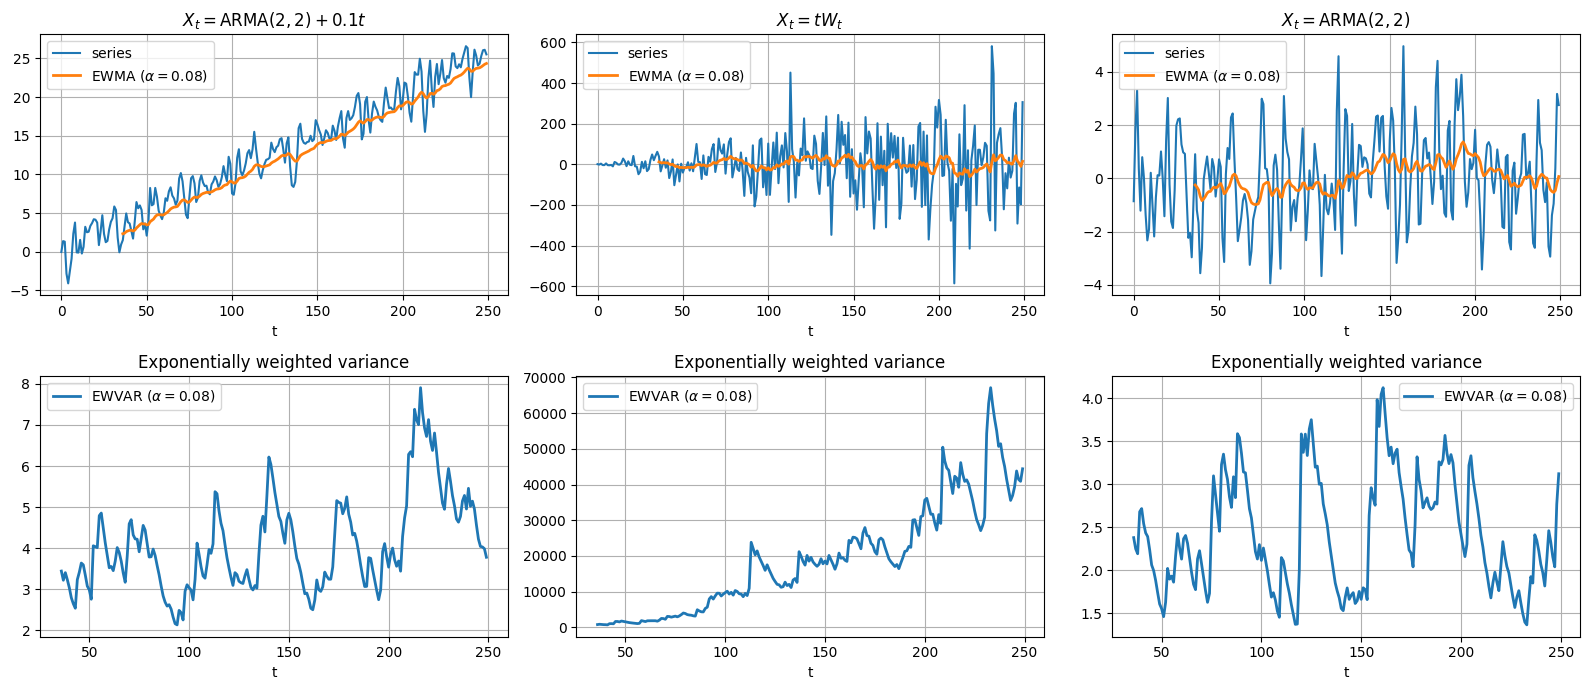

In [ ]:
# ------------------------------------------------------------
# Helpers: EWMA and EWVAR plots
# ------------------------------------------------------------

def plot_ewma(x, alpha=0.1, burn_in=None, ax=None, label=None, lw=2):
    """
    Plot exponentially weighted moving average:
        m_t = alpha x_t + (1-alpha) m_{t-1}
    """

    eps = 0.05

    if burn_in is None:
      burn_in = int(np.ceil(np.log(eps) / np.log(1 - alpha)))

    x = np.asarray(x, dtype=float)
    if ax is None:
        ax = plt.gca()

    m = np.empty_like(x)
    m[0] = x[0]
    for t in range(1, len(x)):
        m[t] = alpha * x[t] + (1 - alpha) * m[t-1]

    ax.plot(np.arange(burn_in, len(x)), m[burn_in:], linewidth=lw, label=label)
    return m

def plot_ewvar(x, alpha=0.1, burn_in=None, ax=None, label=None, lw=2):
    """
    Plot exponentially weighted variance:
        m_t = EWMA(x)
        v_t = alpha (x_t - m_t)^2 + (1-alpha) v_{t-1}
    """


    eps = 0.05

    if burn_in is None:
      burn_in = int(np.ceil(np.log(eps) / np.log(1 - alpha)))

    x = np.asarray(x, dtype=float)
    if ax is None:
        ax = plt.gca()

    # EWMA
    m = np.empty_like(x)
    m[0] = x[0]
    for t in range(1, len(x)):
        m[t] = alpha * x[t] + (1 - alpha) * m[t-1]

    # EWVAR
    v = np.empty_like(x)
    v[0] = 0.0
    for t in range(1, len(x)):
        v[t] = alpha * (x[t] - m[t])**2 + (1 - alpha) * v[t-1]

    ax.plot(np.arange(burn_in, len(x)), v[burn_in:], linewidth=lw, label=label)
    return v


# ------------------------------------------------------------

np.random.seed(0)
n = 250
t = np.arange(1, n + 1)

# ARMA(2,2) parameters
phi = [0.6, -0.3]
theta = [0.7, -0.4]

# 1) ARMA(2,2) + 0.1 t
X_arma2 = gen_arma_sample(phi=phi, theta=theta, n=n, seed=1)
X_arma_trend = X_arma2 + 0.1 * t

# 2) t W_t  (non-stationary in variance)
W = np.random.normal(0, 1, size=n)
X_tW = t * W

# 3) ARMA(2,2)
X_arma3 = gen_arma_sample(phi=phi, theta=theta, n=n, seed=2)


# ------------------------------------------------------------

alpha = 0.08

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=False)

series = [
    (X_arma_trend, r"$X_t = \mathrm{ARMA}(2,2) + 0.1t$"),
    (X_tW,         r"$X_t = tW_t$"),
    (X_arma3,      r"$X_t = \mathrm{ARMA}(2,2)$"),
]

for j, (x, title) in enumerate(series):
    ax = axes[0, j]
    ax.plot(np.arange(0, n), x, label="series")
    plot_ewma(x, alpha=alpha,  ax=ax, label=rf"EWMA ($\alpha={alpha}$)")
    ax.set_title(title)
    ax.set_xlabel("t")
    ax.grid(True)
    ax.legend()

    ax2 = axes[1, j]
    plot_ewvar(x, alpha=alpha, ax=ax2, label=rf"EWVAR ($\alpha={alpha}$)")
    ax2.set_title("Exponentially weighted variance")
    ax2.set_xlabel("t")
    ax2.grid(True)
    ax2.legend()

plt.tight_layout()
plt.show()


### Histograms for visual inspection of normality

A common technique to assess normality is to compare the histogram of the empirical distribution of $X_t$ with the density of a Gaussian distribution having the same mean and variance.  
This visualization helps evaluate whether the data are compatible with a normal distribution by checking whether the overall shapes match.

---

### Examples

We introduce the function `plot_hist` to visualize the empirical distribution of a time series together with the reference density of a standard normal distribution.

The function has a `standardize` parameter; by default, it standardizes the sample (subtracting the mean and dividing by the standard deviation) before plotting.

As an example, we compare the output of `plot_hist` for a Gaussian sample and for a Student-t sample.

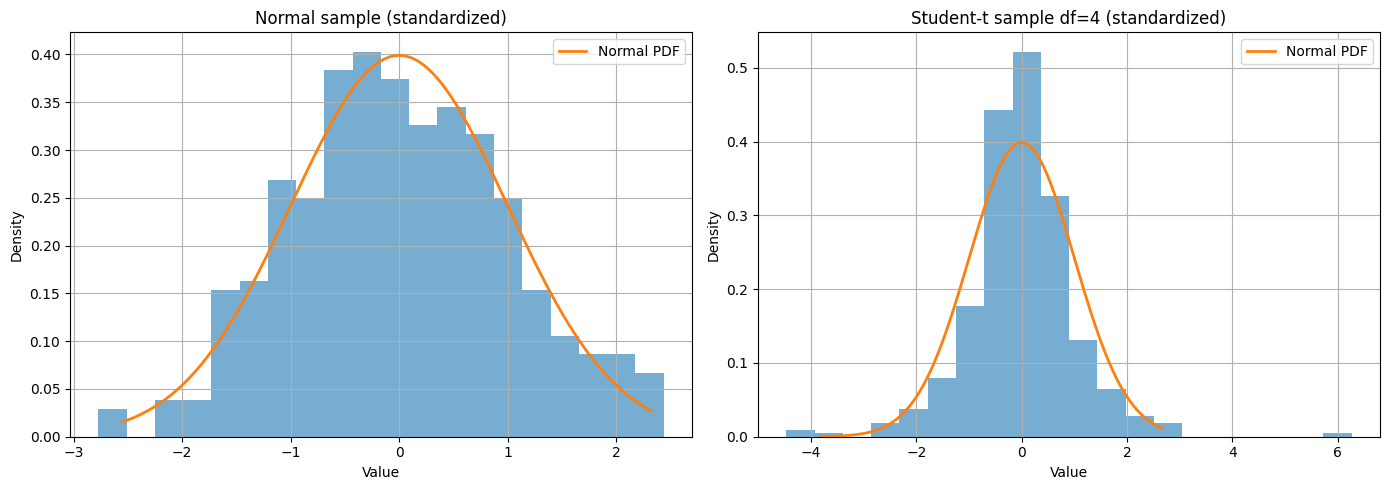

In [ ]:
#################################################
# Histogram plot helper
#################################################

def plot_hist(x, ax=None, bins=None, density=True, overlay="normal",
              overlay_params=None, xlim_quantiles=(0.5, 99.5),
              standardize=True, title=None, grid=True):

    x = np.asarray(x).ravel()

    # Standardize by default
    if standardize:
        mu = np.mean(x)
        sigma = np.std(x, ddof=1)
        if sigma == 0:
            raise ValueError("Standard deviation is zero, cannot standardize.")
        x = (x - mu) / sigma
        std_label = " (standardized)"
    else:
        std_label = ""

    n = len(x)
    if bins is None:
        bins = int(np.sqrt(n))  # automatic bin choice

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    # Histogram
    ax.hist(x, bins=bins, density=density, alpha=0.6)

    # Overlay grid
    q_low, q_high = xlim_quantiles
    xmin, xmax = np.percentile(x, [q_low, q_high])
    grid_x = np.linspace(xmin, xmax, 400)

    # Overlay
    if overlay == "normal":
        if overlay_params is None:
            overlay_params = {"loc": 0.0, "scale": 1.0} if standardize else \
                             {"loc": np.mean(x), "scale": np.std(x, ddof=1)}
        ax.plot(grid_x, stats.norm.pdf(grid_x, **overlay_params),
                linewidth=2, label="Normal PDF")

    elif overlay == "none" or overlay is None:
        pass

    else:
        if overlay_params is None:
            overlay_params = {}
        ax.plot(grid_x, overlay.pdf(grid_x, **overlay_params),
                linewidth=2, label="Overlay PDF")

    ax.set_xlabel("Value")
    ax.set_ylabel("Density" if density else "Count")

    if title is None:
        ax.set_title("Histogram" + std_label)
    else:
        ax.set_title(title)

    if grid:
        ax.grid(True)
    if overlay not in (None, "none"):
        ax.legend()

    return ax


# -----------------------------

np.random.seed(0)
n = 400

x_normal = np.random.normal(2, 5, size=n)

df = 4
x_student = np.random.standard_t(df=df, size=n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_hist(x_normal, ax=axes[0], title="Normal sample (standardized)")
plot_hist(x_student, ax=axes[1], title=f"Student-t sample df={df} (standardized)")

plt.tight_layout()
plt.show()

<a name="s1_4"></a>

## Statistical Tests

In addition to visual tools, there exist formal **statistical tests** to assess whether a linear time series model is appropriate for the data. These tests provide quantitative evidence about key assumptions such as stationarity, presence of autocorrelation, and normality of the residuals.



---

### Augmented Dickey–Fuller test (ADF)

The ADF test is used to assess **stationarity in mean**.

It is based on the regression
$$
\Delta X_t = \alpha + \beta t + \gamma X_{t-1} + \sum_{i=1}^{p} \delta_i \Delta X_{t-i} + W_t,
$$
where additional lagged differences are included to remove autocorrelation.

- **Null hypothesis $H_0$**: the series has a **unit root** (non-stationary in mean).  
- **Alternative hypothesis $H_1$**: the series is **stationary**.

A small p-value leads to rejection of $H_0$, providing evidence of stationarity.

ℹ️  Common implementations (e.g. in `statsmodels`) provide several options and automatic procedures to select the number of lagged differences and deterministic terms.

-------

### Ljung–Box test

The Ljung–Box test is used to assess whether a series is **uncorrelated** up to a given lag $h$.

- **Null hypothesis $H_0$**: $\rho(1)=\rho(2)=\dots=\rho(h)=0$ (no autocorrelation).  
- **Alternative hypothesis $H_1$**: at least one autocorrelation is non-zero.

It tests the **joint significance** of several autocorrelations and is therefore stronger than inspecting individual ACF values.

ℹ️ Unlike the confidence intervals shown by `plot_acf`, the Ljung–Box test evaluates the **joint significance** of all lags up to $h$. It explicitly accounts for the fact that a few sample autocorrelations may appear significant purely by chance.

---

### Jarque–Bera test for normality

Many inferential results for ARIMA models (confidence intervals, prediction intervals) rely on the assumption that residuals are **Gaussian**.

The Jarque–Bera test is a formal test of normality based on **skewness** and **kurtosis**.

- A normal distribution has:
  - skewness = 0,  
  - kurtosis = 3.

- **Null hypothesis $H_0$**: the series is normally distributed.  
- **Alternative hypothesis $H_1$**: the series is not normally distributed.

The test statistic measures how far the sample skewness and kurtosis deviate from these reference values.

---

### Remarks

⚠️ Passing these tests does not *prove* that a model is correct; however, failure usually indicates **model inadequacy**.

ℹ️ There also exist formal tests for **heteroskedasticity** (e.g. ARCH tests), which we do not discuss here.

---

### In practice

The custom function `diagnostic_fn(x, alpha, burn_in)` performs a set of checks using the tools presented above.

Given a series `x`, it:

- plots the time series,
- plots its ACF and PACF,
- plots the exponentially weighted moving average (EWMA) with decay parameter `alpha`,
- plots the histogram of the standardized data for normality inspection,
- performs the Augmented Dickey–Fuller (ADF) test (stationarity in mean).

The parameter `burn_in` specifies the number of initial time steps to discard from *all* diagnostics, in order to avoid initialization artifacts.

⚠️ **Warning.** We omit the Jarque–Bera and Ljung–Box tests from this custom diagnostic function, as they are already implemented and routinely reported in the ARIMA frameworks we will use.

⚠️ **Warning.** When applying `diagnostic_fn` to estimated ARIMA residuals, it is often useful to set  
`burn_in =` (maximum lag used in the model), in order to avoid artifacts due to model initialization.


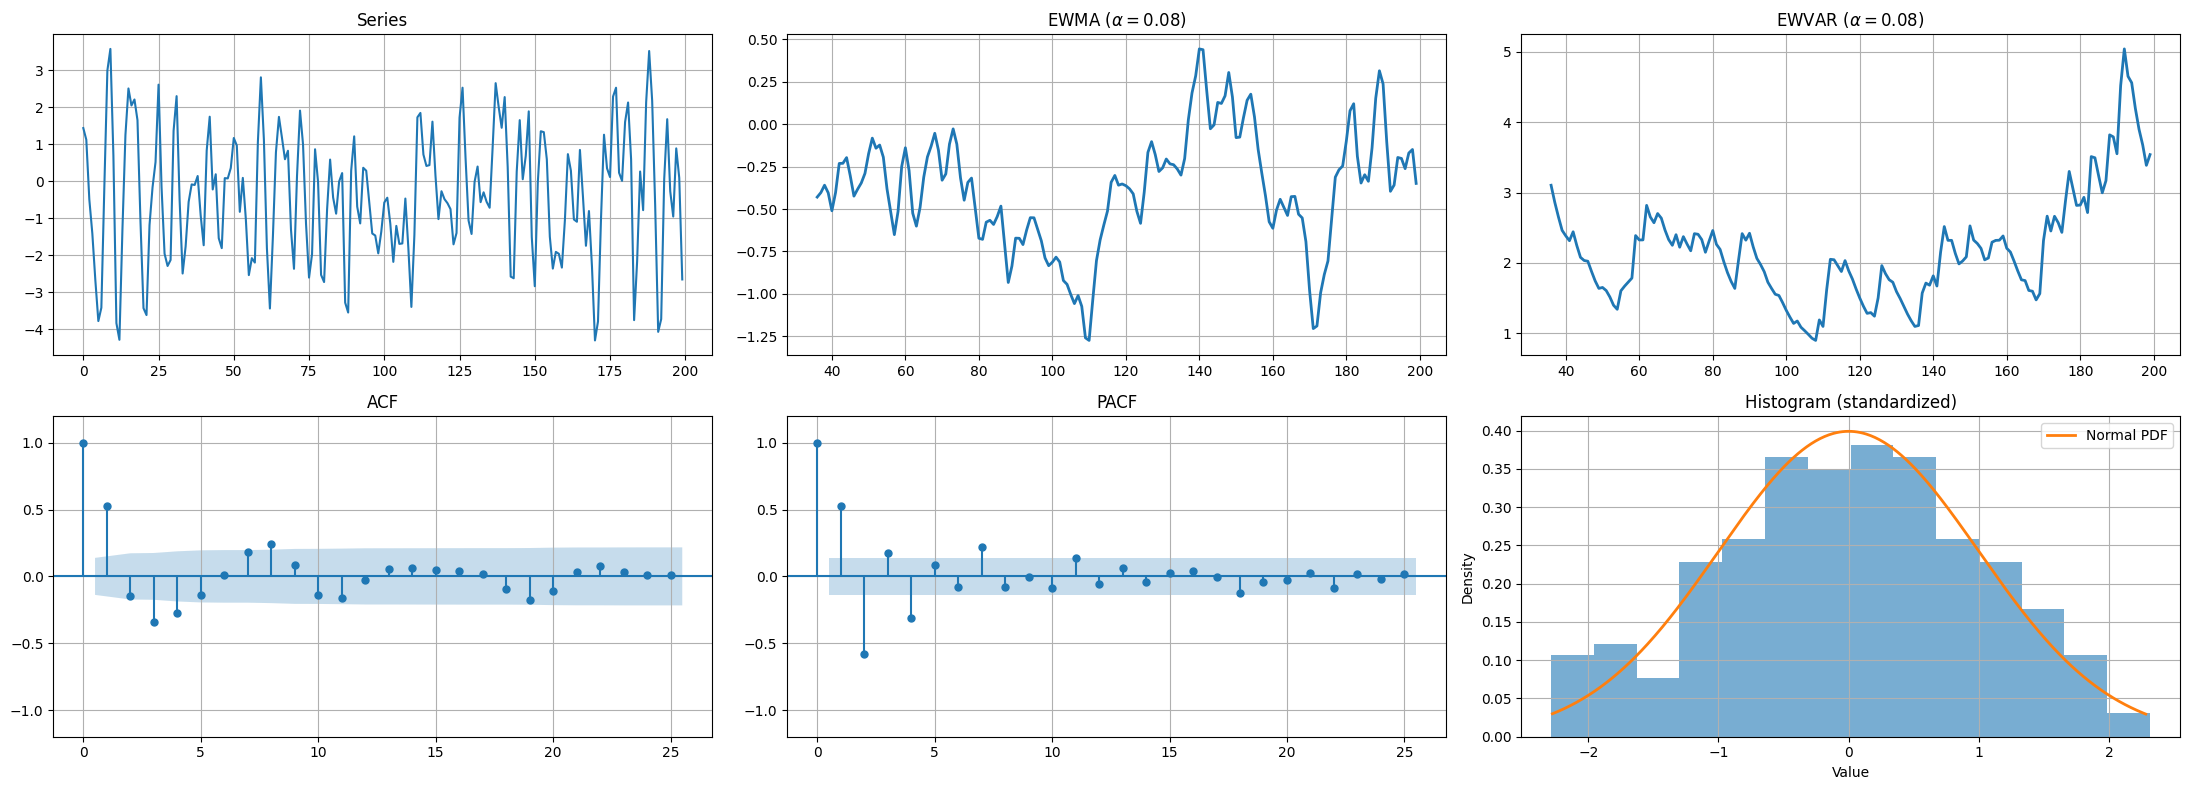

ADF test (H0: unit root / non-stationary in mean)
  ADF stat : -3.45
  p-value  : 0.009382
  used lags: 12



In [ ]:
from statsmodels.tsa.stattools import adfuller


def diagnostic_fn(x, alpha=0.1, burn_in=0, burn_in_ew=None, acf_lags=None):
    """
    Diagnostic grid for a series x.

    Plots (2x3):
      [ series | EWMA | EWVAR ]
      [  ACF   | PACF | HIST  ]

    Also prints: mean, std, t-test for mean=0, and ADF test results.
    """

    # --- Clean input ---
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    # Default settings
    if acf_lags is None:
        acf_lags = min(len(x) // 4, 200)  # cap for readability

    # burn-in for analysis
    x_eff = x[burn_in:]
    if len(x_eff) < 5:
        raise ValueError("Not enough data after burn_in.")


    # --- ADF test ---
    adf_stat, adf_p, usedlag, nobs, crit, _ = adfuller(x_eff, autolag="AIC")

    # --- Plot grid ---
    fig, axes = plt.subplots(2, 3, figsize=(22, 8))

    # series
    axes[0, 0].plot(np.arange(burn_in, burn_in + len(x_eff)), x_eff)
    axes[0, 0].set_title("Series")
    axes[0, 0].grid(True)

    # EWMA (helper)
    plot_ewma(x, alpha=alpha, burn_in=burn_in_ew, ax=axes[0, 1])
    axes[0, 1].set_title(rf"EWMA ($\alpha={alpha}$)")
    axes[0, 1].grid(True)

    # EWVAR (helper)
    plot_ewvar(x, alpha=alpha, burn_in=burn_in_ew, ax=axes[0, 2])
    axes[0, 2].set_title(rf"EWVAR ($\alpha={alpha}$)")
    axes[0, 2].grid(True)

    # ACF
    plot_acf(x_eff, lags=acf_lags, ax=axes[1, 0], alpha=0.05)
    axes[1, 0].set_title("ACF")
    axes[1, 0].set_ylim(-1.2, 1.2)
    axes[1, 0].grid(True)

    # PACF
    plot_pacf(x_eff, lags=acf_lags, ax=axes[1, 1], alpha=0.05, method="ywm")
    axes[1, 1].set_title("PACF")
    axes[1, 1].set_ylim(-1.2, 1.2)
    axes[1, 1].grid(True)

    # Histogram (helper) instead of QQ-plot
    plot_hist(x_eff, ax=axes[1, 2], title="Histogram (standardized)", standardize=True)
    axes[1, 2].grid(True)

    plt.tight_layout()
    plt.show()

    # --- Print results ---

    print("ADF test (H0: unit root / non-stationary in mean)")
    print(f"  ADF stat : {adf_stat:.4g}")
    print(f"  p-value  : {adf_p:.4g}")
    print(f"  used lags: {usedlag}")
    print()

    return {
        "adf_stat": float(adf_stat),
        "adf_pvalue": float(adf_p),
        "adf_usedlag": int(usedlag),
        "nobs_eff": int(nobs),
    }



# ------------------------------------------------------------
# Apply diagnostics to an ARMA(2,2) sample
# ------------------------------------------------------------

n = 200
phi = [0.6, -0.3]
theta = [0.7, -0.2]
X = gen_arma_sample(phi=phi, theta=theta, n=n, seed=0, burn_in=500)

_ = diagnostic_fn(X, alpha=0.08, burn_in=0, acf_lags=25)


<a name="s1_5"></a>

## From ARMA to SARIMAX

ARMA models are appropriate for **weakly stationary processes**.  
However, many real-world time series exhibit trends, seasonal patterns, and dependence on external variables, which cannot be adequately captured by simple ARMA models.

To address these limitations, several important extensions have been developed, leading to the SARIMAX framework, which incorporates:
- **differencing** to handle non-stationarity (I),
- **seasonal components** to model periodic behavior (S),
- and **exogenous variables** to include external information (X).

These models significantly broaden the class of time series that can be represented and forecast in practice.


---

### (I) ARIMA: Detrending with Iterated differences

An **ARIMA($p,d,q$)** process is defined as
$$
\phi(L)\,(1 - L)^d X_t = \theta(L)\, W_t,
$$
where

- $L$ is the lag operator, $LX_t = X_{t-1}$,
- $(1-L)^d$ is the differencing operator (to remove trends),
- $\phi(L) = 1 - \phi_1 L - \dots - \phi_p L^p$,
- $\theta(L) = 1 + \theta_1 L + \dots + \theta_q L^q$,
- $\{W_t\}$ is a white noise process.

ARIMA models are used for **non-stationary series in mean** that become stationary after differencing.


---

### Examples

We now consider two simple non-stationary series obtained by adding white noise to a polynomial trend:

- **Linear trend (degree 1)**:
  $$
  X_t^{(1)} = \alpha_0 + \alpha_1 t + W_t.
  $$
  Applying one difference removes the linear trend:
  $$
  (1-L)X_t^{(1)} = X_t^{(1)} - X_{t-1}^{(1)} = \alpha_1 + (W_t - W_{t-1}),
  $$
  which is a **constant drift** $\alpha_1$ plus an **MA(1)** noise term $W_t - W_{t-1}$.

- **Quadratic trend (degree 2)**:
  $$
  X_t^{(2)} = \alpha_0 + \alpha_1 t + \alpha_2 t^2 + W_t.
  $$
  Here one difference is not enough: we need a second difference,
  $$
  (1-L)^2 X_t^{(2)} = X_t^{(2)} - 2X_{t-1}^{(2)} + X_{t-2}^{(2)}
  = 2\alpha_2 + (W_t - 2W_{t-1} + W_{t-2}),
  $$
  which is a **constant drift** $2\alpha_2$ plus an **MA(2)** noise term.

In the next cells we will simulate these two processes and show that:
- the **first difference** $(1-L)$ turns a linear trend into a **drift + MA(1)**,
- the **second difference** $(1-L)^2$ turns a quadratic trend into a **drift + MA(2)**.


ADF p-value for X1: 0.9824
ADF p-value for (1-L)X1: 9.196e-17

ADF p-value for X2: 1
ADF p-value for (1-L)X2: 0.6751
ADF p-value for (1-L)^2 X2: 4.155e-14


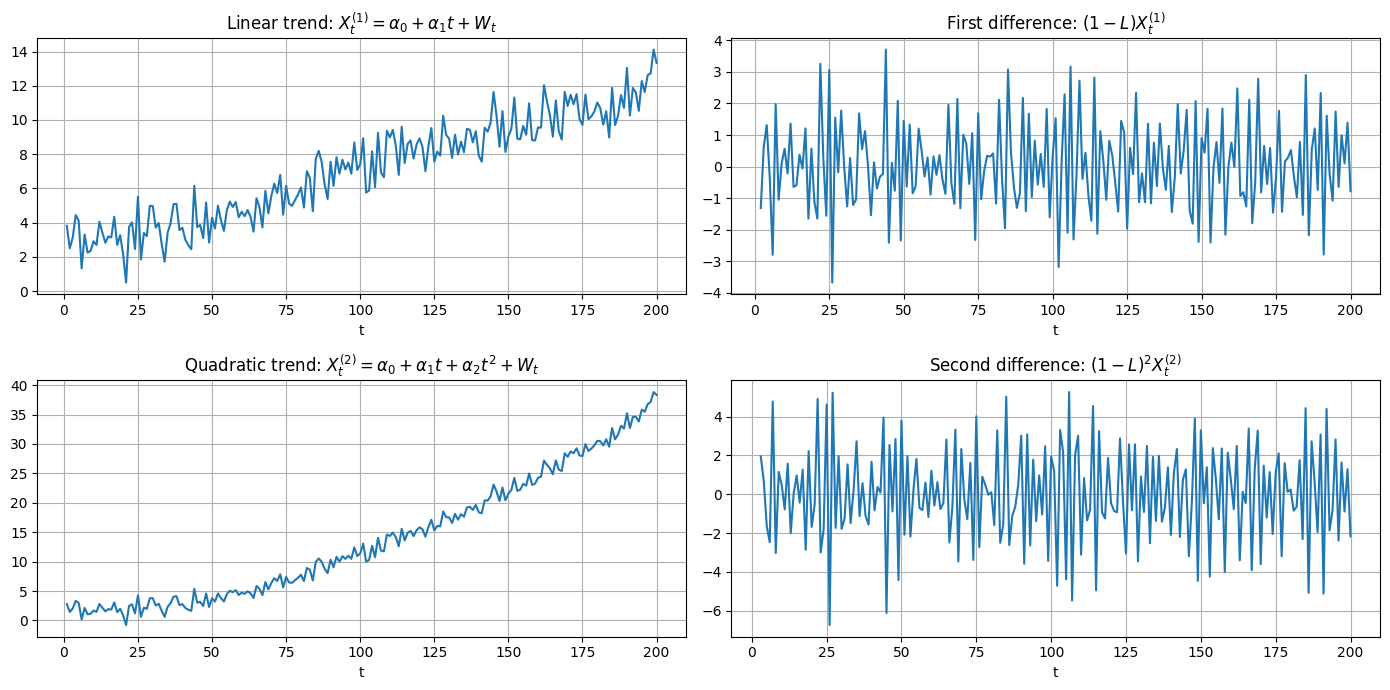

In [ ]:

np.random.seed(0)

n = 200
t = np.arange(1, n + 1)

# White noise
sigma = 1.0
W = np.random.normal(0, sigma, size=n)

# Linear trend: X_t = a0 + a1 t + W_t
a0_1, a1_1 = 2.0, 0.05
X1 = a0_1 + a1_1 * t + W

# Quadratic trend: X_t = a0 + a1 t + a2 t^2 + W_t
a0_2, a1_2, a2_2 = 1.0, 0.02, 0.0008
X2 = a0_2 + a1_2 * t + a2_2 * (t**2) + W

# ------------------------------------------------------------

# (1-L)X_t = X_t - X_{t-1}
X1_delta = np.diff(X1, n=1)
X2_delta = np.diff(X2, n=1)

# (1-L)^2 X_t = X_t - 2X_{t-1} + X_{t-2}
X2_delta2 = np.diff(X2, n=2)

# ------------------------------------------------------------


adf_p_X1 = adfuller(X1, autolag="AIC")[1]
adf_p_X1_delta = adfuller(X1_delta, autolag="AIC")[1]

adf_p_X2 = adfuller(X2, autolag="AIC")[1]
adf_p_X2_delta = adfuller(X2_delta, autolag="AIC")[1]
adf_p_X2_delta2 = adfuller(X2_delta2, autolag="AIC")[1]


print(f"ADF p-value for X1: {adf_p_X1:.4g}")
print(f"ADF p-value for (1-L)X1: {adf_p_X1_delta:.4g}")
print()
print(f"ADF p-value for X2: {adf_p_X2:.4g}")
print(f"ADF p-value for (1-L)X2: {adf_p_X2_delta:.4g}")
print(f"ADF p-value for (1-L)^2 X2: {adf_p_X2_delta2:.4g}")


# ------------------------------------------------------------


fig, axes = plt.subplots(2, 2, figsize=(14, 7))

axes[0, 0].plot(t, X1)
axes[0, 0].set_title(r"Linear trend: $X^{(1)}_t = \alpha_0 + \alpha_1 t + W_t$")
axes[0, 0].set_xlabel("t")
axes[0, 0].grid(True)

axes[0, 1].plot(t[1:], X1_delta)
axes[0, 1].set_title(r"First difference: $(1-L)X^{(1)}_t$")
axes[0, 1].set_xlabel("t")
axes[0, 1].grid(True)


axes[1, 0].plot(t, X2)
axes[1, 0].set_title(r"Quadratic trend: $X^{(2)}_t = \alpha_0 + \alpha_1 t + \alpha_2 t^2 + W_t$")
axes[1, 0].set_xlabel("t")
axes[1, 0].grid(True)

axes[1, 1].plot(t[2:], X2_delta2)
axes[1, 1].set_title(r"Second difference: $(1-L)^2X^{(2)}_t$")
axes[1, 1].set_xlabel("t")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


<a name="e1_5_1"></a>

### Exercise 1.5.1

Consider the process
$$
X_t = \left(\frac{t}{10}\right)^2 \log\!\left(\frac{t}{100}+1\right) + W_t,
\qquad W_t \sim N(0,1).
$$
Simulate a sample for $t=0,1,\dots,150$.

For each $d=0,1,2,3$:
- compute the differenced series $(1-L)^d X_t$,
- plot $(1-L)^d X_t$,
- run the ADF test using `adfuller(s, autolag="AIC")` and report the p-value.

Based on the plots and the ADF results, which differencing order $d$ would you choose to obtain a series that is (approximately) stationary?


**Solution 1.5.1**

ADF p-values
D = 0: p-value = 0.9975
D = 1: p-value = 0.9986
D = 2: p-value = 1.791e-09
D = 3: p-value = 7.728e-11


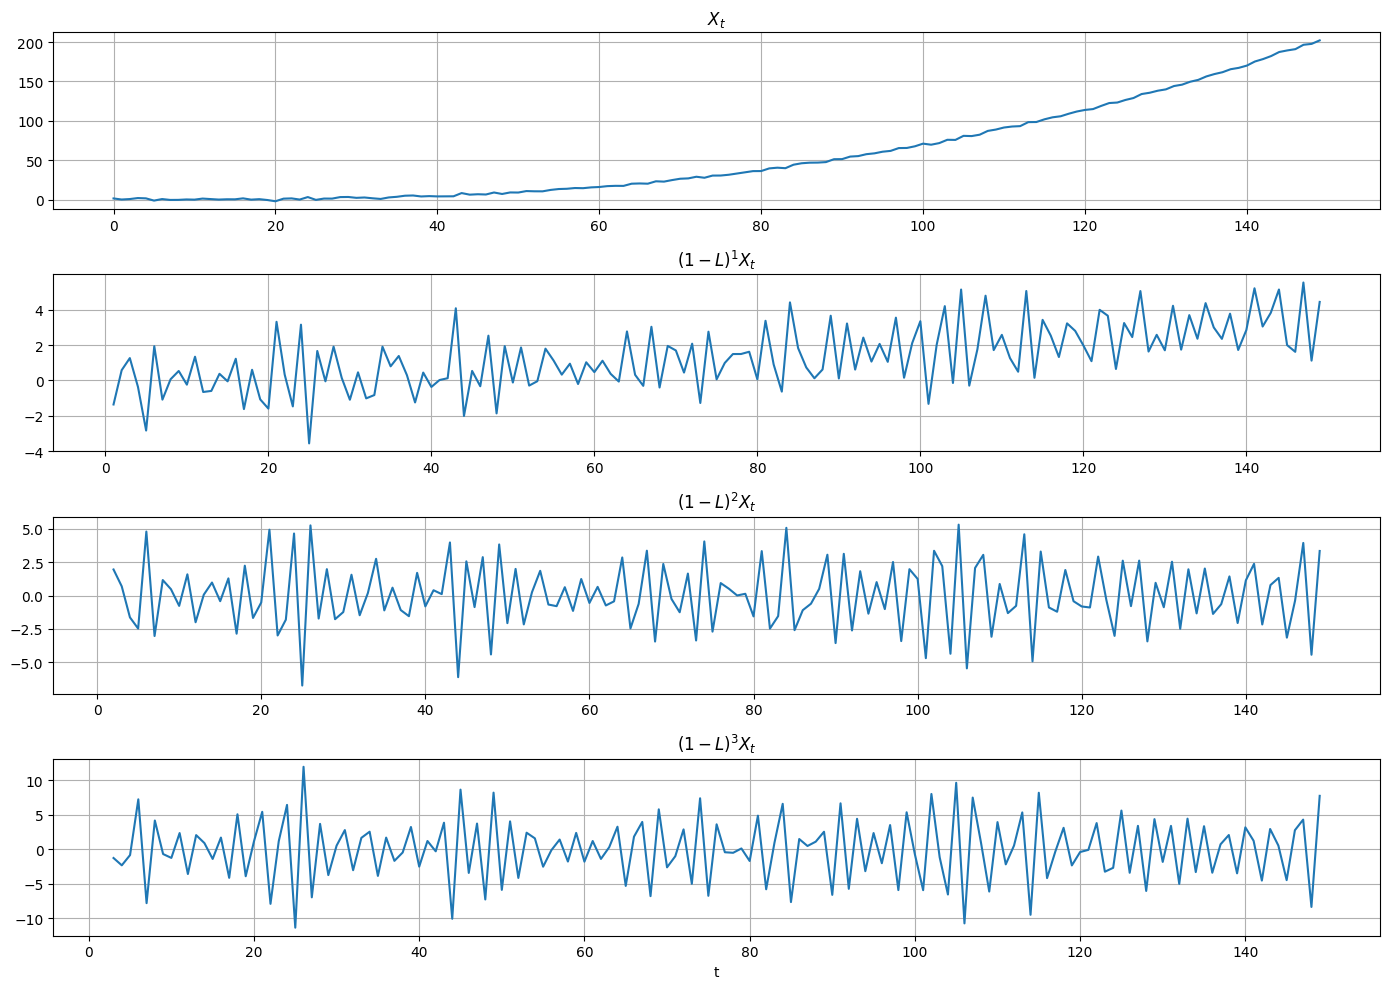

In [ ]:
np.random.seed(0)

n = 150
t = np.arange(n)

sigma = 1.0
W = np.random.normal(0, sigma, size=n)

X = (t/10)**2 * np.log( (t/100)+ 1) + W

# ------------------------------------------------------------

max_D = 3
series = [X]
labels = [r"$X_t$"]

for d in range(1, max_D + 1):
    series.append(np.diff(X, n=d))
    labels.append(rf"$(1-L)^{d} X_t$")

# ------------------------------------------------------------

print("ADF p-values")
for d, s in enumerate(series):
    pval = adfuller(s, autolag="AIC")[1]
    print(f"D = {d}: p-value = {pval:.4g}")

# ------------------------------------------------------------

fig, axes = plt.subplots(max_D + 1, 1, figsize=(14, 10), sharex=False)

for i, (ax, s, lab) in enumerate(zip(axes, series, labels)):
    ax.plot(t[i:], s)
    ax.set_title(lab)
    ax.grid(True)

axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()


### (S) SARIMA: Seasonal differences to model periodicity

A **seasonal ARIMA** model **SARIMA($p,d,q$)$\times$($P,D,Q, s$)$_s$** is defined as
$$
\phi(L)\,\Phi(L^s)\,(1-L)^d(1-L^s)^D X_t
= \theta(L)\,\Theta(L^s)\,W_t.
$$

From a theoretical point of view, **SARIMA models do not differ from ARIMA models**: they are ARIMA models written in a way that **separates ordinary and seasonal components**. In particular,

- $s$ is the seasonal period,
- seasonal AR/MA terms are distinguished from non-seasonal ones,
- seasonal differencing $(1-L^s)^D$ is separated from ordinary differencing $(1-L)^d$.


---

### Examples

We generate a **SARIMA(1,0,1)$\times$(1,0,2)$_7$** process using `gen_arma_sample` by constructing **sparse** AR and MA coefficient arrays (zeros at non-used lags).

We then plot the **ACF** and **PACF**:
- over all lags (standard diagnostics),
- and only at **seasonal lags** (multiples of $s=7$) to highlight the seasonal dependence structure.


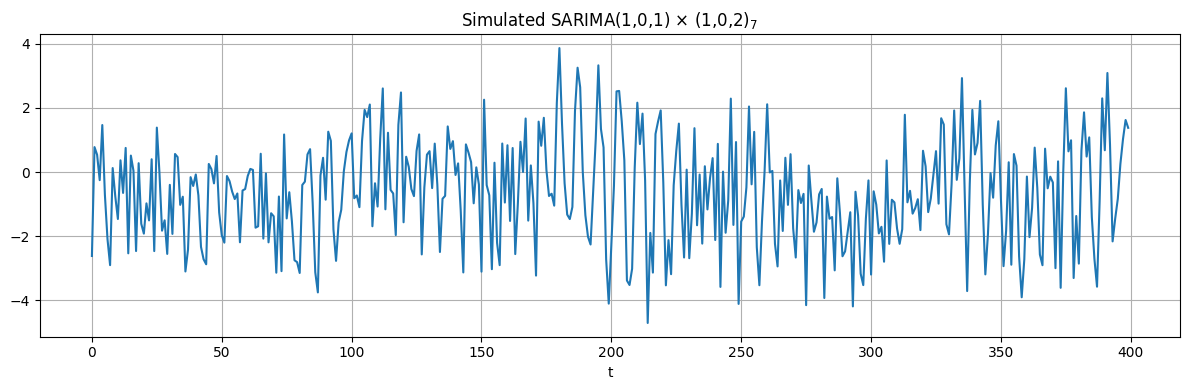

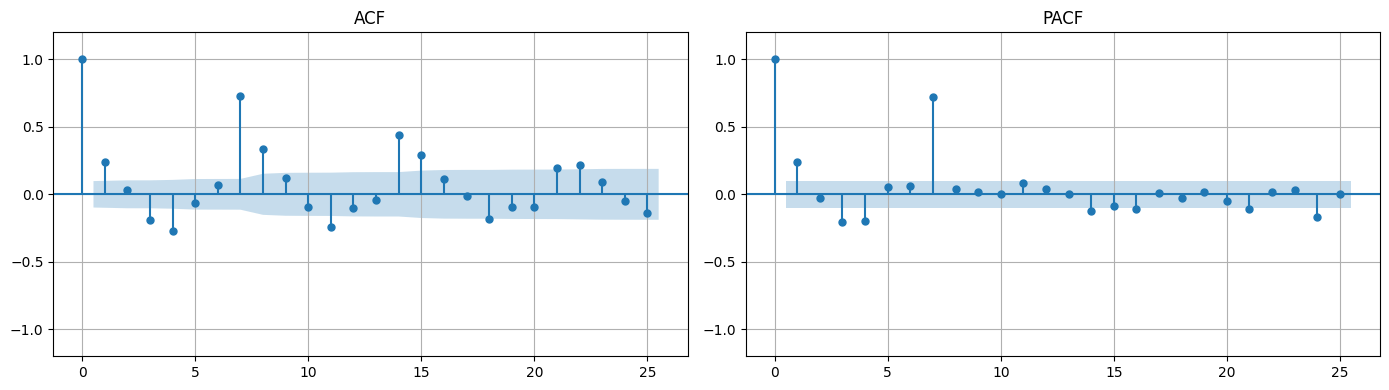

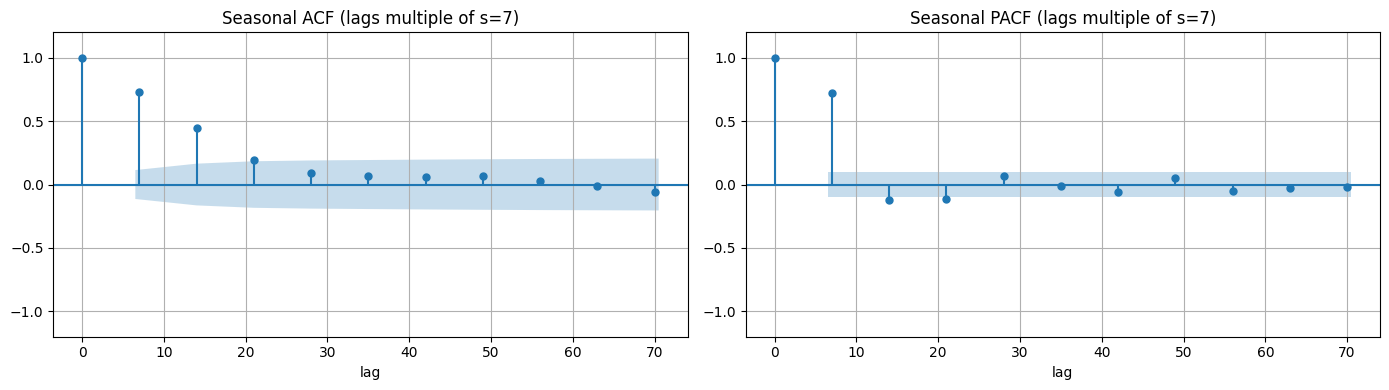

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ------------------------------------------------------------
# Generating SARIMA(1,0,1) x (1,0,2)_7
# ------------------------------------------------------------

phi1   = 0.3
Phi1   = 0.4

theta1 = -0.2
Theta1 = 0.4
Theta2 = 0.3

s = 7

phi = np.zeros(7)
phi[0] = phi1
phi[6] = Phi1

theta = np.zeros(14)
theta[0]  = theta1
theta[6]  = Theta1
theta[13] = Theta2

n = 400
X = gen_arma_sample(phi=phi, theta=theta, n=n, burn_in=300, seed=0)

# ------------------------------------------------------------

max_lags = 25

plt.figure(figsize=(12, 4))
plt.plot(X)
plt.title("Simulated SARIMA(1,0,1) × (1,0,2)$_7$")
plt.xlabel("t")
plt.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(X, lags=max_lags, ax=axes[0], alpha=0.05)
axes[0].set_ylim(-1.2, 1.2)
axes[0].set_title("ACF")
axes[0].grid(True)

plot_pacf(X, lags=max_lags, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_ylim(-1.2, 1.2)
axes[1].set_title("PACF")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Seasonal ACF & PACF only
# ------------------------------------------------------------


def plot_seasonal_acf_and_pacf(X, s, max_seasonal_lags=None):
  if max_seasonal_lags is None:
    max_seasonal_lags = min(10, len(X)//(2*s))

  seasonal_lags = [k * s for k in range(0, max_seasonal_lags + 1)]

  fig, axes = plt.subplots(1, 2, figsize=(14, 4))

  plot_acf(X, lags=seasonal_lags, ax=axes[0], alpha=0.05)
  axes[0].set_ylim(-1.2, 1.2)
  axes[0].set_title(f"Seasonal ACF (lags multiple of s={s})")
  axes[0].set_xlabel("lag")
  axes[0].grid(True)

  plot_pacf(X, lags=seasonal_lags, ax=axes[1], alpha=0.05, method="ywm")
  axes[1].set_ylim(-1.2, 1.2)

  axes[1].set_title(f"Seasonal PACF (lags multiple of s={s})")
  axes[1].set_xlabel("lag")
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()


plot_seasonal_acf_and_pacf(X, s)


### (X) SARIMAX: Including external explanatory variables

A **SARIMAX** model extends SARIMA by including **exogenous regressors** $\{Z_t\}$:
$$
\phi(L)\,\Phi(L^s)\,(1-L)^d(1-L^s)^D X_t
= \theta(L)\,\Theta(L^s)\,W_t + \beta^\top Z_t.
$$
Here $Z_t$ is a vector of external covariates and $\beta$ is the associated coefficient vector.

**Special case: deterministic intercept/trend**

A deterministic component can be included by choosing $Z_t$ as simple functions of time, e.g. $Z_t=1$ (intercept) or $Z_t=t$ (linear trend).  
In `statsmodels`, this is handled via the `trend` option:

- `"n"`: no deterministic term,
- `"c"`: constant (intercept),
- `"t"`: linear trend,
- `"ct"`: constant + linear trend.

⚠️ In this course we will mainly use the special case above (intercept and/or linear trend), rather than general exogenous regressors.

---

<a name="s2"></a>

# Estimation and forecasting with SARIMAX

SARIMAX models are typically fitted by **maximum likelihood estimation (MLE)**.  
Once the parameters are estimated, forecasts are obtained as the **conditional expected values of future observations given the observed past**.

In this section, we explore the most common software implementations and illustrate how to fit SARIMAX models and produce forecasts in practice.


<a name="s2_1"></a>

## Maximum Likelihood Estimation

Given a SARIMAX specification $(p,d,q)x(P,D,Q)_s$, the $p + q + P + Q$ parameters  of the non-seasonal and seasonal AR and MA parts, together with the regression coefficients $\beta$ (if present) and the variance $\sigma^2$ of the white noise, are estimated by **maximum likelihood**.

In maximum likelihood estimation, the unknown parameters are chosen to **maximize the log-likelihood function**
$$
\ell(\theta) = \log p(X_1,\dots,X_T \mid \theta),
$$
that is, the logarithm of the probability (density) of the observed data under the model.

Estimation is typically performed under the assumption that the innovations satisfy
$$
W_t \sim N(0,\sigma^2),
$$
that is, $W_t$ is Gaussian white noise (zero mean, constant variance, and no autocorrelation).

⚠️ **Warning.** The Gaussian assumption, together with zero autocorrelation and constant variance, implies that $\{W_t\}$ is **independent and identically distributed (i.i.d.)**. This is a much stronger condition than simple uncorrelatedness, and stronger than what is guaranteed by the Wold decomposition.

⚠️ **Warning.** Maximum likelihood estimation for ARMA/SARIMA models requires **stationarity of the AR part** and **invertibility of the MA part** in order for the likelihood to be well-behaved and the model to be identifiable.

ℹ️ Under the distributional assumptions, maximum likelihood estimation allows one to construct confidence intervals for **model parameters** and for **future predictions**.

### Model selection

Classical time series methodology alternates between **estimation, diagnostic checking, and model refinement**.  
The goal is to select a SARIMAX specification that both fits the data well and produces residuals compatible with white noise.

---

### Diagnostic checks

After fitting a model, diagnostic tests are performed on the **residuals** $\widehat W_t$ (estimated innovations).

#### Ljung–Box test (uncorrelatedness)

The Ljung–Box test is used to assess whether residuals are **uncorrelated** up to a given lag.

✅ **If $H_0$ is not rejected** (large p-values):  
the residuals are compatible with white noise. The model is adequate in capturing the linear dependence structure.

❌ **If $H_0$ is rejected** (small p-values):  
there is remaining autocorrelation, indicating **underfitting**. One should consider:
- increasing AR or MA orders,
- revising differencing orders $d, D$,
- modifying the seasonal period $s$,
- or adding missing components.

⚠️ **Warning.** If the series exhibits very rich dynamics or multiple seasonal patterns, SARIMA models may be insufficient, and more structured approaches (e.g. deterministic components or richer models) may be required.

#### Normality and Heteroskedasticity checks

Normality tests (e.g. **Jarque–Bera**) and tests for **heteroskedasticity** are performed on the residuals $\widehat{W}_t$.

❌ If these tests fail, the Gaussian assumption becomes unreliable. As a consequence, **confidence intervals for parameters and forecasts should not be trusted**, and this typically signals **model inadequacy**.

---

### Information criteria

When several SARIMAX models are plausible, objective criteria are needed to compare them. **Information criteria** balance **goodness of fit** and **model complexity**.

For a fitted model with log-likelihood $\ell$, $k$ estimated parameters, and $n$ observations:

- **Akaike Information Criterion (AIC)**  
  $$
  \mathrm{AIC} = -2\ell + 2k
  $$

- **Bayesian Information Criterion (BIC)**  
  $$
  \mathrm{BIC} = -2\ell + k \log n
  $$

- **Hannan–Quinn Information Criterion (HQIC)**  
  $$
  \mathrm{HQIC} = -2\ell + 2k \log(\log n)
  $$

All criteria penalize model complexity, with increasing strength:
$$
\text{AIC} \;<\; \text{HQIC} \;<\; \text{BIC}.
$$

- AIC tends to favor richer models.  
- BIC is more conservative.  
- HQIC lies between the two.

The preferred model is the one with the **smallest value** of the chosen criterion.

---

### Remarks

Information criteria are **only meaningful when comparing models fitted to the same data under the same transformations**.

In particular, they can only be compared between models that share:
- the **same time series**,
- the **same differencing structure**,
- the **same seasonal period and regressors**.

They **cannot** be used to compare models built on different transformations or different samples, since the likelihoods are not commensurable.

For this reason, information criteria are tools for **model selection within a fixed modeling framework**, not across fundamentally different modeling choices.

---

### Examples: Fit a model

We simulate a sample of length $n=1000$ from an **ARMA(2,1)** process with  
$$
(\phi_1,\phi_2) = (0,\,0.6),
\qquad
\theta_1 = 0.3,
$$
and then fit a model using the `SARIMAX` class from `statsmodels.tsa`.

Specifically, we fit an **ARMA(2,2)** model (slightly over-parameterized) to illustrate maximum likelihood estimation and residual diagnostics.


In [ ]:
phi = [0.0, 0.6]
theta = [0.3,]

n = 1000
X = gen_arma_sample(phi=phi, theta=theta, n=n, seed=12)

# -------------------------------------------------- #

model = sm.tsa.SARIMAX(X, order=(2, 0, 2))
model = model.fit(disp=True)
print(model.summary())

# Collects IC

ic_table = pd.DataFrame(columns=["model", "AIC", "BIC", "HQIC"])

ic_table.loc[len(ic_table)] = [
    "ARMA(2,2)",
    model.aic,
    model.bic,
    model.hqic
]

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(2, 0, 2)   Log Likelihood               -1423.770
Date:                Wed, 18 Mar 2026   AIC                           2857.539
Time:                        11:47:00   BIC                           2882.078
Sample:                             0   HQIC                          2866.866
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0026      0.040      0.067      0.947      -0.075       0.080
ar.L2          0.6567      0.039     16.909      0.000       0.581       0.733
ma.L1          0.2911      0.050      5.805      0.0

### Examples: Output interpretation

From the fitted model summary, we observe:

✅ **`Prob(Q) = 0.98`**  
Ljung–Box test p-value. There is no evidence of residual autocorrelation.

✅ **`Prob(JB) = 0.37`**  
Jarque–Bera test p-value. Residuals are compatible with normality.

✅ **`Prob(H) (two-sided) = 0.73`**  
Test for heteroskedasticity. There is no evidence of non-constant variance.

❌ **`ma.L2  P>|z| = 0.242`**  
The z-test does not reject $H_0 : \theta_2 = 0$. The second MA coefficient is not statistically significant.

❌ **`ar.L1  P>|z| = 0.947`**  
The z-test does not reject $H_0 : \phi_1 = 0$. The first AR coefficient is not statistically significant.

This points out that the fitted ARMA(2,2) model is likely **over-parameterized**, and that a simpler structure may be sufficient.

---

⚠️ **Convergence warnings**

When fitting ARMA/SARIMAX models, it is common for the optimizer to raise *convergence warnings*.  
These indicate that the numerical algorithm was not fully able to certify that a maximum of the likelihood was reached.

A convergence warning does **not automatically invalidate** the fitted model, but it signals that parameter estimates and inferential quantities (standard errors, confidence intervals) should be treated with caution.

We will not go into further detail here. Students who plan to rely on confidence intervals or hypothesis tests are encouraged to consult the library documentation and experiment with different optimization options.


----

### Examples: Constrained models

Since `ma.L2` is not statistically significant, we first reduce the model order to **ARMA(2,1)**.

The diagnostic checks remain satisfactory, but the coefficient `ar.L1` is still not significant.

In this case, we cannot remove it simply by further reducing the AR order, since the second AR lag is needed. Instead, we show how to fit a model where some parameters are **manually constrained** to fixed values (typically zero).

This allows us to obtain a model that:
- passes all diagnostic checks, and  
- has only statistically significant parameters.

Finally, we compare the three fitted models using **information criteria**.  
As expected, these improve as we iteratively remove insignificant parameters, reflecting a better trade-off between goodness of fit and model complexity.


In [ ]:
# Fit ARMA(2, 1)

model = sm.tsa.SARIMAX(X, order=(2, 0, 1))
model = model.fit(disp=True)
print(model.summary())

ic_table.loc[len(ic_table)] = [
    "ARMA(2,1)",
    model.aic,
    model.bic,
    model.hqic
]


# Fit ARMA(2,1) with the constraint ar.L1=0

model = sm.tsa.SARIMAX(X,
                       order=(2, 0, 1),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

constraints_dict = {"ar.L1": 0.0}
with model.fix_params(constraints_dict):
    model = model.fit(disp=True)

print(model.summary())


ic_table.loc[len(ic_table)] = [
    "ARMA(2,2) ar.L1=0",
    model.aic,
    model.bic,
    model.hqic
]


ic_table

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(2, 0, 1)   Log Likelihood               -1424.529
Date:                Wed, 18 Mar 2026   AIC                           2857.059
Time:                        11:47:01   BIC                           2876.690
Sample:                             0   HQIC                          2864.520
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0140      0.042      0.331      0.741      -0.069       0.097
ar.L2          0.6168      0.026     23.475      0.000       0.565       0.668
ma.L1          0.2855      0.052      5.537      0.0

,model,AIC,BIC,HQIC
0,"ARMA(2,2)",2857.539416,2882.078192,2866.865863
1,"ARMA(2,1)",2857.058880,2876.689902,2864.520038
2,"ARMA(2,2) ar.L1=0",2847.431422,2862.148681,2853.025551


<a name="s2_2"></a>

## AutoARIMA

In practice, model identification can be automated by performing a **grid search** over a plausible class of models and comparing the fitted candidates using **information criteria** (AIC, BIC, HQIC).

This approach is commonly referred to as **AutoARIMA**.

However, automatic procedures are rarely fully “blind”. A preliminary **exploratory data analysis (EDA)** is usually necessary to:

- choose appropriate **differencing orders** (to detect and remove trends),
- identify possible **seasonal behavior** and select a seasonal period $s$,
- determine reasonable **maximum orders** for the AR, MA, and seasonal components.

Once this is done, AutoARIMA typically consists of:

1. performing a systematic or stepwise search over candidate SARIMAX models,
2. selecting the best models according to an information criterion,
3. evaluating the leading candidates through **diagnostic checks** on the residuals.

AutoARIMA should therefore be seen as a tool to **support** model identification, not to replace statistical reasoning or residual analysis.

ℹ️ An **exhaustive (grid) search** fits all models in a predefined grid of orders. It is guaranteed to find the best model but is computationally expensive.  A **stepwise search** explores the model space adaptively using heuristic improvement strategies, reducing computation time at the cost of possibly missing the global optimum.




---
### In Practice: `pmarima.auto_arima`


We will use the function `auto_arima` from the library `pmdarima`. The most important parameters controlling the model space are:



- **`max_p, max_q`** : maximum values for the non-seasonal AR and MA orders.

- **`max_P, max_Q`** : maximum values for the seasonal AR and MA orders.

- **`max_order`** : maximum allowed value for \(p+q+P+Q\) (controls overall model complexity).

- **`seasonal`** (`True/False`) : whether to include seasonal terms.

- **`m`** : the seasonal period \(s\) (e.g. 12 for monthly data, 7 for weekly patterns).

- **`information_criterion`** : criterion used for comparison (`"aic"`, `"bic"`, `"hqic"`).

- **`stepwise`** (`True/False`) : whether to use a stepwise (heuristic) search or an exhaustive grid search.

---

ℹ️ `auto_arima` can automatically select:

- the **non-seasonal differencing order** \(d\),
- the **seasonal differencing order** \(D\),

using unit-root type tests (e.g. ADF).

Relevant parameters include:

- **`d`, `D`** (set to `None` for automatic selection).

---

ℹ️ By default, `auto_arima` uses:

- `with_intercept=True`,
- `trend=None`.

In practice, this means that the procedure will **also explore models with and without a constant term**, and retain the best choice according to the selected information criterion.

---

ℹ️ When `stepwise=True`, the algorithm starts from an initial model and iteratively increases or decreases the orders while searching for improvements. In this case, the following parameters are relevant:

- **`start_p, start_q`**  
  initial values for the non-seasonal AR and MA orders.

- **`start_P, start_Q`**  
  initial values for the seasonal AR and MA orders.


---

❌ `auto_arima` **cannot automatically infer the seasonal period** \(s\).  

---

### Example

We generate a synthetic **SARIMA(2,1,3)$\times$(1,1,1)$_{12}$** process with $n=1000$ observations and then apply `auto_arima`, using **BIC** as the selection criterion.  

The function is allowed to automatically infer the differencing orders ($d$ and $D$), while selecting the remaining AR and MA orders by minimizing the chosen information criterion.

⚠️ `pmdarima` is a wrapper built on top of `statsmodels`.  To access the underlying `statsmodels.tsa.statespace.sarimax.SARIMAXResults` object, use `model.arima_res_` .





In [ ]:
n = 1000
order = (1, 1, 2)
seasonal_order = (0, 1, 1, 12)

sim_model = sm.tsa.SARIMAX(
    endog=np.zeros(1),
    order=order,
    seasonal_order=seasonal_order,
)

# Parameter vector order in statsmodels:
# [AR (p) | MA (q) | seasonal AR (P) | seasonal MA (Q) | sigma2]
params = np.array([
    0.4,

    0.5, 0.2,

   -0.5,           # seasonal MA(1): Theta1 at lag 12
    1.0            # sigma^2
])

X = sim_model.simulate(params, nsimulations=n, random_state=12)


# --------------------------------------------------------------------------

model = sm.tsa.SARIMAX(X, order=order, seasonal_order=seasonal_order)
model = model.fit(disp=True)
print(model.summary())

type_m1 = type(model)


# AutoArima

model = pm.auto_arima(
    X,
    seasonal=True,
    m=12,

    d=None, D=None,            # let auto_arima infer differencing orders

    start_p=0, start_q=0,
    max_p=4, max_q=4,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    max_order=5,

    information_criterion="bic",
    stepwise=True,
    trace=True,
    error_action="ignore"
)

print(model.summary())


print()
print(f"Type statsmodel.tsa.SARIMAX: {type_m1}")
print(f"Type pm.auto_arima: {type(model)}")
print(f"Type pm.auto_arima.arima_res_: {type(model.arima_res_)}")


                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 1000
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood               -1427.464
Date:                              Wed, 18 Mar 2026   AIC                           2864.928
Time:                                      11:47:03   BIC                           2889.401
Sample:                                           0   HQIC                          2874.235
                                             - 1000                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3368      0.070      4.813      0.000       0.200       0.474
ma.L1          0.54

<a name="e2_2_1"></a>

### Exercise 2.2.1

The data in `synthetic_train.csv` have been generated from a specific SARIMA model. Load the series using `pandas` and perform an exploratory data analysis.

Your task is to identify and fit a SARIMA model that:

- passes the main diagnostic checks (Ljung–Box for uncorrelatedness, Jarque–Bera for normality, and a test for heteroskedasticity),
- has only **statistically significant parameters** (based on the z-tests).

You may use either a manual search or `auto_arima`.

**Hint.** Restricting the overall complexity to  
$$
p + q + P + Q \le 5
$$
is sufficient.


In [ ]:
# Your solution here

<a name="s2_3"></a>

## Mean prediction

Once a SARIMA/SARIMAX model has been fitted, future values are predicted using the **conditional mean** of the process given the observed past data:

$$
\widehat X_{t+h} = \mathbb{E}\!\left[X_{t+h}\mid X_t, X_{t-1}, \dots \right].
$$

The integer $h$ denotes the **prediction horizon** (or **$h$-step ahead forecast**).

There are two typical situations:

- **Fixed-origin forecast.**  
  Given the last available observation at time $n$, we forecast a future period of length $H$:
  $$
  \widehat X_{n+h}, \qquad h = 1, \dots, H.
  $$

- **Rolling forecast.**  
  As new observations are acquired over time, we repeatedly update the model and predict at a fixed horizon:
  $$
  \widehat X_{k+h}, \qquad k = n, n+1, \dots
  $$



---

ℹ️ **Remark.** Under the Gaussian assumption on the innovations, the forecast distribution is also Gaussian. This allows the construction of **prediction intervals** together with the mean forecast.

---

⚠️ For a **stationary** ARMA model, as the horizon $h$ increases, the mean prediction converges to a constant value (the unconditional mean of the process). This reflects the fact that, far in the future, the influence of the observed past progressively vanishes.  

### In Practice: Forecasting Utilities

We provide two custom helper functions that wrap the `statsmodels` forecasting interface and expose a simplified, consistent API for common evaluation settings:

- `predict_fixed_origin(model, H, conf_interval=None)`  
- `predict_rolling_horizon(model, X_train, X_test, h, refit=False, fill=False, conf_interval=None)`

Both functions return the forecast means and, optionally, confidence intervals.

---

**Parameters**

- **`model`**  
  A fitted `statsmodels` SARIMAX results object (`SARIMAXResults`).

- **`H`**  
  Forecast length for **fixed-origin** forecasting. The function predicts the next $H$ future values from the end of the training sample.

- **`h`**  
  Prediction horizon for **rolling** forecasting. At each update step, the function predicts $h$ steps ahead.

- **`refit`**  
  Controls how new observations are incorporated during rolling forecasts:
  - If `True`, the model is re-estimated at each step using an expanding window.
  - If `False`, parameters are kept fixed and only the internal Kalman state is updated.

- **`fill`**  
  Only relevant for rolling forecasts.  
  If `True`, the first $h-1$ test points are filled using shorter horizons
  $$
  1, \dots, h-1.
  $$
  If `False`, these entries are left as `NaN`.

- **`conf_interval`**  
  If not `None`, interpreted as the significance level $\alpha$  
  (e.g. `0.05` for $95\%$ confidence intervals).  
  If `None`, confidence intervals are not computed.

---

**Example usage**

In the following examples, we will:

- Apply both forecasting strategies to a simulated process,

- Plot the resulting predictions,

- Compute and compare the RMSE obtained by each method.

---
⚠️ `pmdarima` is a wrapper built on top of `statsmodels`.  
To access the underlying `SARIMAXResults` object required by these functions, use `model = model.arima_res_` .

⚠️ Refitting SARIMA at every rolling step replaces optimal state filtering with noisy parameter re-estimation and often increases RMSE instead of reducing it.


Fixed-origin test RMSE: 1.660829522764094


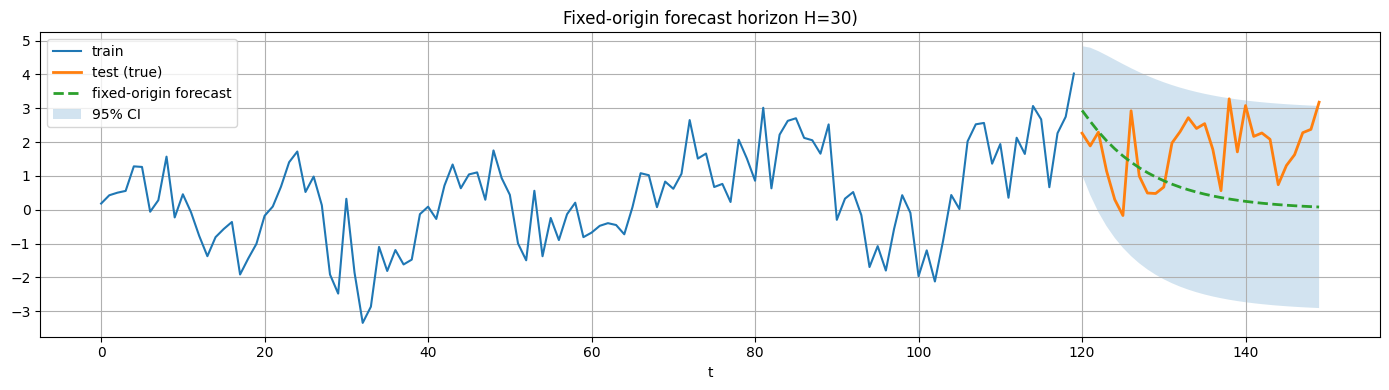

Rolling forecast h=1 test RMSE: 1.0087645405270633


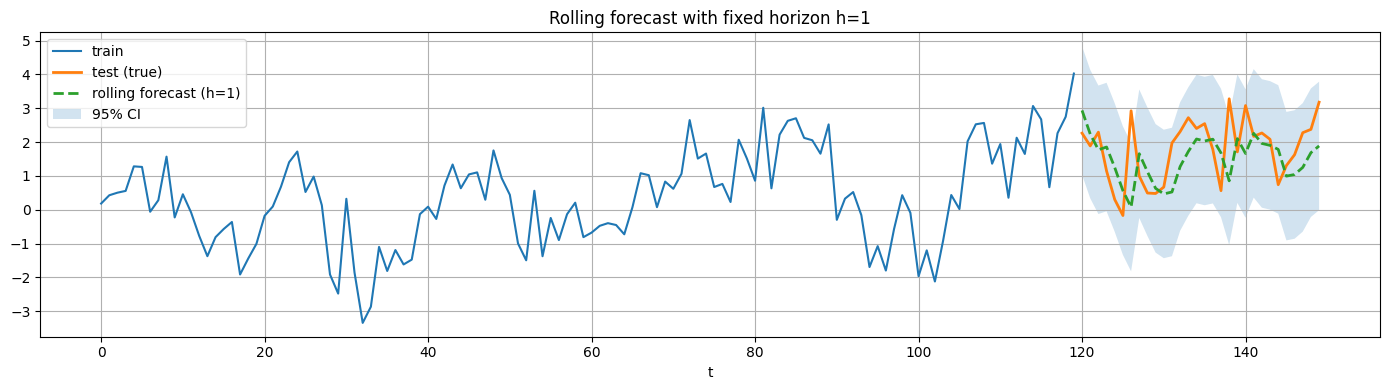

In [ ]:
def predict_fixed_origin(model, H, conf_interval=None):
    """
    Fixed-origin multi-step forecasting.

    Parameters
    ----------
    model : statsmodels.tsa.statespace.sarimax.SARIMAXResults
        A fitted SARIMA/SARIMAX results object (e.g., res = SARIMAX(...).fit()).
    H : int
        Forecast horizon (number of future steps): predicts X_{n+1}, ..., X_{n+H}.
    conf_interval : float or None
        If not None, interpreted as alpha for confidence intervals (e.g., 0.05 for 95% CI).
        If None, confidence intervals are not returned.

    Returns
    -------
    preds : np.ndarray
        Array of length H containing the fixed-origin forecasts.
    cis : np.ndarray or None
        If conf_interval is not None, returns an array of shape (H, 2)
        with [lower, upper] bounds aligned to preds. Otherwise None.
    """
    if H < 1:
        raise ValueError("H must be >= 1")

    cis = None
    if conf_interval is not None:
        alpha = float(conf_interval)
        if not (0 < alpha < 1):
            raise ValueError("conf_interval must be in (0,1), e.g. 0.05")

    fc = model.get_forecast(steps=H)
    preds = np.asarray(fc.predicted_mean, dtype=float)

    if conf_interval is None:
        return preds, None

    ci_obj = fc.conf_int(alpha=alpha)

    # statsmodels may return a pandas DataFrame or ndarray
    if hasattr(ci_obj, "to_numpy"):
        ci_arr = ci_obj.to_numpy(dtype=float)
    else:
        ci_arr = np.asarray(ci_obj, dtype=float)

    # Ensure shape (H,2)
    if ci_arr.ndim != 2 or ci_arr.shape[0] != H or ci_arr.shape[1] < 2:
        raise ValueError("Unexpected confidence interval shape returned by statsmodels.")

    ci_arr = ci_arr[:, :2]
    return preds, ci_arr


def predict_rolling_horizon(model, X_train, X_test, h, refit=False, fill=False, conf_interval=None):
    """
    Rolling forecasting at fixed horizon h with optional warm-start filling.

    Key idea (timing):
    - At test origin t (0-based), we forecast using information up to t-1 (train + test[:t]).
    - Then we update the filter with the newly observed X_test[t].

    Parameters
    ----------
    model : statsmodels.tsa.statespace.sarimax.SARIMAXResults
        A fitted SARIMA/SARIMAX results object.
    X_train : array-like
        Initial observed history.
    X_test : array-like
        Sequential test observations.
    h : int
        Forecast horizon (>=1). For h=1, this is one-step-ahead.
    refit : bool
        If True, refit parameters at each step on expanding data.
        If False, keep parameters fixed and only update state.
    fill : bool
        If True, fill preds[0..h-2] using 1-step-ahead rolling forecasts.
        If False, leave them NaN.
    conf_interval : float or None
        If not None, interpreted as alpha (e.g. 0.05 for 95% CI).

    Returns
    -------
    preds : np.ndarray, shape (len(X_test),)
        Rolling forecasts aligned to X_test indices.
    cis : np.ndarray or None, shape (len(X_test), 2)
        Lower/upper bounds aligned to preds if conf_interval is not None, else None.
    """
    X_train = np.asarray(X_train, dtype=float).ravel()
    X_test  = np.asarray(X_test,  dtype=float).ravel()
    n_test  = len(X_test)

    if h < 1:
        raise ValueError("h must be >= 1")

    preds = np.full(n_test, np.nan, dtype=float)

    cis = None
    if conf_interval is not None:
        alpha = float(conf_interval)
        if not (0 < alpha < 1):
            raise ValueError("conf_interval must be in (0,1), e.g. 0.05")
        cis = np.full((n_test, 2), np.nan, dtype=float)

    def _ci_row(ci_obj, idx):
        # idx: 0-based step within the forecast horizon
        if hasattr(ci_obj, "iloc"):  # pandas DataFrame
            return float(ci_obj.iloc[idx, 0]), float(ci_obj.iloc[idx, 1])
        return float(ci_obj[idx, 0]), float(ci_obj[idx, 1])

    # Keep a reference to the original model specification for refitting
    base_model = model.model

    # Current results object (state / params)
    res = model

    # Helper: update with observed y, then optionally refit at the end
    def _update_then_maybe_refit(res_obj, t_obs):
        """
        Update state with X_test[t_obs], then optionally refit on expanding data.
        Returns updated results object.
        """
        y_new = [X_test[t_obs]]

        # 1) Always update the state first (cheap)
        res_updated = res_obj.append(y_new, refit=False)

        # 2) Optionally refit at the end (expensive)
        if refit:
            y_expanding = np.concatenate([X_train, X_test[:t_obs + 1]])
            mod = base_model.clone(endog=y_expanding)
            return mod.fit(disp=False)

        return res_updated

    # ------------------------------------------------------------
    # Loop A: fill=True warm start
    # Fill preds[0..h-2] using repeated 1-step-ahead forecasts.
    # ------------------------------------------------------------
    t = 0
    if fill and h > 1:
        fill_until = min(h - 1, n_test)  # number of indices to fill: 0..fill_until-1
        while t < fill_until:
            # Forecast NEXT step (targets X_test[t])
            fc = res.get_forecast(steps=1)
            mean_fc = np.asarray(fc.predicted_mean)
            preds[t] = float(mean_fc[0])

            if cis is not None:
                ci_obj = fc.conf_int(alpha=alpha)
                cis[t, 0], cis[t, 1] = _ci_row(ci_obj, 0)

            # Now update with the actual observation X_test[t]
            res = _update_then_maybe_refit(res, t)
            t += 1

    # ------------------------------------------------------------
    # Loop B: true h-step rolling forecasts
    # For origins t = current t .. n_test - h:
    # forecast h steps ahead and store at index (t + h - 1).
    # ------------------------------------------------------------
    last_origin = n_test - h
    while t <= last_origin:
        fc = res.get_forecast(steps=h)
        mean_fc = np.asarray(fc.predicted_mean)

        target = t + h - 1
        preds[target] = float(mean_fc[h - 1])

        if cis is not None:
            ci_obj = fc.conf_int(alpha=alpha)
            cis[target, 0], cis[target, 1] = _ci_row(ci_obj, h - 1)

        # Update with the actual observation at time t
        res = _update_then_maybe_refit(res, t)
        t += 1

    return preds, cis


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))



# ------------------------------------------------------------
n = 150
order = (2, 0, 1)
seasonal_order = None #(1, 0, 1, 6)

sim_model = sm.tsa.SARIMAX(
    endog=np.zeros(1),  # dummy placeholder (not used for simulation)
    order=order,
    seasonal_order=seasonal_order,
    trend="n",
    enforce_stationarity=True,
    enforce_invertibility=True,
)

# Parameter vector order in statsmodels:
# [AR (p) | MA (q) | seasonal AR (P) | seasonal MA (Q) | sigma2]
params = np.array([
    0.8, 0.15,       # AR
    -0.3,       # MA
    #0.4,        # seasonal MA(1) at lag 12
    #-0.2,
    1.        # sigma^2
])

X_train_and_test = sim_model.simulate(params, nsimulations=n, random_state=12)

# ------------------------------------------------------------

n = 120
X = X_train_and_test[:n]
X_test  = X_train_and_test[n:]

# ------------------------------------------------------------

model = sm.tsa.SARIMAX(X, order=order, seasonal_order=seasonal_order).fit(disp=False)


# ------------------------------------------------------------
# Fixed-origin forecast h = 1, 2, ... , H
# ------------------------------------------------------------

H = len(X_test)
alpha = 0.05

pred, ci = predict_fixed_origin(model, H, conf_interval=alpha)

ci_low = ci[:, 0]
ci_up = ci[:, 1]

fo_rmse = rmse(X_test, pred)
print("Fixed-origin test RMSE:", fo_rmse)


# ------------------------------------------------------------
# Plot fixed-origin forecast vs test with CI
# ------------------------------------------------------------

t = np.arange(n + H)
t_train = np.arange(n)
t_test  = np.arange(n, n + H)

plt.figure(figsize=(14, 4))
plt.plot(t_train, X, label="train")
plt.plot(t_test, X_test, label="test (true)", linewidth=2)
plt.plot(t_test, pred, "--", label="fixed-origin forecast", linewidth=2)
plt.fill_between(t_test, ci_low, ci_up, alpha=0.2, label="95% CI")
plt.title(f"Fixed-origin forecast horizon H={H})")
plt.xlabel("t")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Rolling forecast with fixed horizon h=1
# For each k, fit on X[:k+1] and forecast X_{k+h} (k = n, n+1, ... , n + n_test - 1)
# ------------------------------------------------------------

h = 1

pred, ci = predict_rolling_horizon(model, X, X_test, h=h, conf_interval=alpha)

ci_low = ci[:, 0]
ci_up = ci[:, 1]

rf_rmse = rmse(X_test[h-1:], pred[h-1:])
print(f"Rolling forecast h={h} test RMSE:", rf_rmse)


# ------------------------------------------------------------
# Plot: rolling h-step forecast vs true with CI
# ------------------------------------------------------------

mask_roll = ~np.isnan(pred)


plt.figure(figsize=(14, 4))
plt.plot(t_train, X, label="train")
plt.plot(t_test, X_test, label="test (true)", linewidth=2)
plt.plot(t_test[mask_roll], pred[mask_roll], "--", label=f"rolling forecast (h={h})", linewidth=2)
plt.fill_between(t_test[mask_roll], ci_low[mask_roll], ci_up[mask_roll], alpha=0.2, label="95% CI")
plt.title(f"Rolling forecast with fixed horizon h={h}")
plt.xlabel("t")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




In [ ]:
number = 1
repeat = 2

h = 1

t_true = timeit.repeat(lambda: predict_rolling_horizon(model, X, X_test, h=h, refit=True), number=number, repeat=repeat)
t_false = timeit.repeat(lambda: predict_rolling_horizon(model, X, X_test, h=h, refit=False), number=number, repeat=repeat)


per_call_true = [t / number for t in t_true]
per_call_false = [t / number for t in t_false]

print(f"predict_rolling_horizon(..., refit=True) : "
          f"best={min(per_call_true):.6f}s  mean={sum(per_call_true)/len(per_call_true):.6f}s  "
          f"(number={number}, repeat={repeat})")

print(f"predict_rolling_horizon(..., refit=False): "
          f"best={min(per_call_false):.6f}s  mean={sum(per_call_false)/len(per_call_false):.6f}s  "
          f"(number={number}, repeat={repeat})")


predict_rolling_horizon(..., refit=True) : best=2.224882s  mean=2.292707s  (number=1, repeat=2)
predict_rolling_horizon(..., refit=False): best=0.192245s  mean=0.194793s  (number=1, repeat=2)


<a name="e2_3_1"></a>

### Exercise 2.3.1

Using the same training set `synthetic_train.csv` and the fitted SARIMA model obtained in Exercise 2.2.1 (you may copy–paste your final model specification and fitting code here), load the test set in `synthetic_test.csv` with $
n_{\text{test}} = 100$.

Your goal is to evaluate the forecasting performance of the model using our helper functions:

1. Using `predict_fixed_origin` with $H = n_{\text{test}}$,
   compute the fixed-origin predictions on the test set and report the corresponding RMSE using `rmse`.

2. For each horizon $h = 1,2,\dots,15$, use `predict_rolling_horizon`
   to produce rolling forecasts and compute the RMSE for each horizon.

3. Print:
   - the RMSE for the fixed-origin forecast,
   - the RMSE for each rolling horizon $h=1,\dots,15$.

### Notes

- Use $\texttt{refit=False}$ for rolling forecasts.

In [ ]:
## Your solution here

## Exercise 2.3.2

We consider the classical monthly airline passenger time series available in  
`sm.datasets.get_rdataset("AirPassengers").data`.

This dataset contains the total number of international airline passengers (in thousands), measured monthly from **January 1949 to December 1960**.

We use the **last two years of observations (January 1959 – December 1960)** as the **test set**, while all earlier observations (**January 1949 – December 1958**) form the **training set**.

The objective is to compare different modeling strategies based on their **out-of-sample forecasting performance** over this two-year horizon.

---

### Instructions

- Apply a transformation of your choice to stabilize the variance of the series (e.g., to make it approximately homoscedastic and closer to normality).  
  **This transformation must be kept fixed across all methods.**

- Compare the **RMSE** obtained from a **rolling forecast evaluation** with forecasting horizons  
  $h = 1, \dots, 12$, using three approaches applied to the transformed series:

  1. A method based solely on **SARIMAX** techniques.
  2. A method based solely on **deterministic components** (e.g., trend and seasonality).
  3. A **hybrid method** combining both approaches.

---

### Important Notes

1. The **test set must not be used** at any stage of model selection, transformation choice, or parameter estimation.  
  It must be used **only for evaluating the RMSE**.

2. If a transformation is applied to the training data, you must **apply the inverse transformation** to the forecasts before computing the RMSE.

In [ ]:
class PolyTrendDecomposer:
    """
    Decompose x_t = m(t) + r_t where m(t) is a deterministic polynomial trend.

    Input: x is a 1D numpy array (assumed observed at t = 0,1,...,n-1).
    """

    def __init__(self, degree=1):
        self.degree = int(degree)
        self.coef_ = None   # highest power first (np.polyfit convention)
        self.n_ = None

    def fit(self, x):
        x = np.asarray(x, dtype=float).ravel()
        n = x.size
        t = np.arange(n, dtype=float)

        self.coef_ = np.polyfit(t, x, deg=self.degree)
        self.n_ = n
        return self

    def trend(self, x=None):
        if self.coef_ is None:
            raise RuntimeError("Call fit(x) first.")
        n = self.n_ if x is None else np.asarray(x).size
        t = np.arange(n, dtype=float)
        return np.polyval(self.coef_, t)

    def residuals(self, x):
        x = np.asarray(x, dtype=float).ravel()
        if self.coef_ is None:
            self.fit(x)
        return x - self.trend(x)

    def fit_transform(self, x):
        self.fit(x)
        tr = self.trend()
        res = np.asarray(x, dtype=float).ravel() - tr
        return tr, res

    def forecast_trend(self, h):
        if self.coef_ is None or self.n_ is None:
            raise RuntimeError("Call fit(x) first.")
        h = int(h)
        if h <= 0:
            raise ValueError("h must be a positive integer.")
        t_future = np.arange(self.n_, self.n_ + h, dtype=float)
        return np.polyval(self.coef_, t_future)




class FourierSeasonalityDecomposer:
    """
    Deterministic seasonality via truncated Fourier series.

    Model (no trend here):
        x_t = S(t) + r_t
    where
        S(t) = a0 + sum_{k=1}^K [ a_k cos(2π k t / s) + b_k sin(2π k t / s) ].

    Input: x is a 1D numpy array observed at t = 0,1,...,n-1.
    """

    def __init__(self, s, K=2):
        self.s = int(s)     # period (in samples)
        self.K = int(K)     # number of harmonics
        self.beta_ = None
        self.N_ = None

    def _design(self, t):
        t = np.asarray(t, dtype=float)
        cols = [np.ones_like(t)]
        for k in range(1, self.K + 1):
            cols.append(np.cos(2 * np.pi * k * t / self.s))
            cols.append(np.sin(2 * np.pi * k * t / self.s))
        return np.column_stack(cols)

    def fit(self, x):
        x = np.asarray(x, dtype=float).ravel()
        self.N_ = x.size
        t = np.arange(self.N_, dtype=float)

        A = self._design(t)
        self.beta_, *_ = np.linalg.lstsq(A, x, rcond=None)
        return self

    def seasonality(self, n=None):
        if self.beta_ is None:
            raise RuntimeError("Call fit(x) first.")
        n = self.N_ if n is None else int(n)
        t = np.arange(n, dtype=float)
        return self._design(t) @ self.beta_

    def residuals(self, x):
        x = np.asarray(x, dtype=float).ravel()
        if self.beta_ is None:
            self.fit(x)
        return x - self.seasonality(n=x.size)

    def fit_transform(self, x):
        x = np.asarray(x, dtype=float).ravel()
        self.fit(x)
        s_comp = self.seasonality()
        r = x - s_comp
        return s_comp, r

    def forecast_seasonality(self, h):
        if self.beta_ is None or self.N_ is None:
            raise RuntimeError("Call fit(x) first.")
        h = int(h)
        if h <= 0:
            raise ValueError("h must be a positive integer.")
        t_future = np.arange(self.N_, self.N_ + h, dtype=float)
        return self._design(t_future) @ self.beta_


def plot_periodogram(x, figsize=(12, 4), title="Periodogram"):
    """
    Compute and plot the periodogram of a 1D series.
    """
    freq, Pxx = periodogram(np.asarray(x))

    plt.figure(figsize=figsize)
    plt.plot(freq, Pxx, linewidth=1.2)
    plt.title(title, fontsize=13)
    plt.xlabel("Frequency (cycles per sample)")
    plt.ylabel("Power")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return freq, Pxx


def print_top_spectral_peaks(x, k=10):
    """
    Compute the periodogram and print the top k spectral peaks.
    """
    freq, Pxx = periodogram(np.asarray(x))

    top_idx = np.argsort(Pxx)[::-1][:k]

    print(f"Top {k} spectral peaks:")

    for i, idx in enumerate(top_idx, start=1):
        f = freq[idx]
        power = Pxx[idx]
        period = np.inf if f == 0 else 1.0 / f

        print(f"{i:2d}) freq = {f:.6f} cycles/sample | "
              f"period ≈ {period:.2f} samples | "
              f"power = {power:.6g}")


def plot_seasonal_acf_and_pacf(X, s, max_seasonal_lags=None):
  if max_seasonal_lags is None:
    max_seasonal_lags = min(10, len(X)//(2*s))

  seasonal_lags = [k * s for k in range(0, max_seasonal_lags + 1)]

  fig, axes = plt.subplots(1, 2, figsize=(14, 4))

  plot_acf(X, lags=seasonal_lags, ax=axes[0], alpha=0.05)
  axes[0].set_ylim(-1.2, 1.2)
  axes[0].set_title(f"Seasonal ACF (lags multiple of s={s})")
  axes[0].set_xlabel("lag")
  axes[0].grid(True)

  plot_pacf(X, lags=seasonal_lags, ax=axes[1], alpha=0.05, method="ywm")
  axes[1].set_ylim(-1.2, 1.2)

  axes[1].set_title(f"Seasonal PACF (lags multiple of s={s})")
  axes[1].set_xlabel("lag")
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()



class BoxCoxTransformer(BaseEstimator, TransformerMixin):
    """
    Box-Cox transform with optional shift to ensure positivity.
    Works on 1D or (n_samples, 1) arrays.
    """
    def __init__(self, shift=0.0, eps=1e-6):
        self.shift = shift
        self.eps = eps

    def fit(self, X, y=None):
        x = np.asarray(X).reshape(-1)
        x_shifted = x + self.shift

        min_val = np.min(x_shifted)
        if min_val <= 0:
            # adjust shift so all values become > 0
            self.shift_ = self.shift + (-min_val + self.eps)
            x_shifted = x + self.shift_
        else:
            self.shift_ = self.shift

        # estimate lambda via MLE
        _, self.lambda_ = boxcox(x_shifted, lmbda=None)
        return self

    def transform(self, X):
        x = np.asarray(X).reshape(-1) + self.shift_
        x = np.clip(x, self.eps, None)
        xt = boxcox(x, lmbda=self.lambda_)
        return xt.reshape(-1, 1)

    def inverse_transform(self, X):
        z = np.asarray(X).reshape(-1)
        x_shifted = inv_boxcox(z, self.lambda_)
        x = x_shifted - self.shift_
        return x.reshape(-1, 1)


class LogitTransformer(BaseEstimator, TransformerMixin):
    """
    Logit transform for data in (0, 1).
    Clips to [eps, 1-eps] for numerical stability.
    """
    def __init__(self, eps=1e-6):
        self.eps = eps

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        x = np.asarray(X).reshape(-1)
        x = np.clip(x, self.eps, 1 - self.eps)
        z = np.log(x / (1 - x))
        return z.reshape(-1, 1)

    def inverse_transform(self, X):
        z = np.asarray(X).reshape(-1)
        x = 1 / (1 + np.exp(-z))
        return x.reshape(-1, 1)

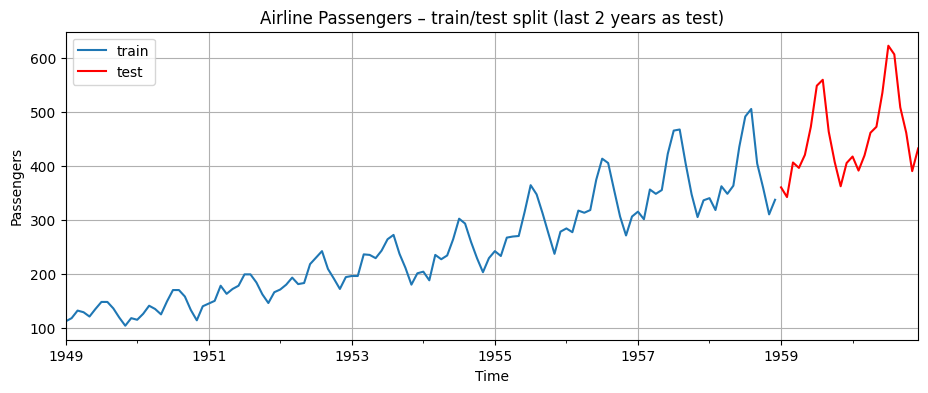

Train period: 1949-01-01 to 1958-12-01
Test period : 1959-01-01 to 1960-12-01


In [ ]:

# Load dataset
data = sm.datasets.get_rdataset("AirPassengers").data

# Put into pandas Series with datetime index
dates = pd.date_range(start="1949-01-01", periods=len(data), freq="MS")
ts = pd.Series(data["value"].values, index=dates, name="AirPassengers")

# Split: last 2 years = 24 months as test set
train = ts.iloc[:-24]
test = ts.iloc[-24:]

# Plot train/test split
plt.figure(figsize=(11,4))
train.plot(label="train")
test.plot(label="test", color="red")
plt.title("Airline Passengers – train/test split (last 2 years as test)")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

print("Train period:", train.index[0].date(), "to", train.index[-1].date())
print("Test period :", test.index[0].date(), "to", test.index[-1].date())
